In [2]:

%matplotlib inline 
from os import listdir
from os.path import isfile, join
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from matplotlib import pyplot as plt
import math
import gensim
import gensim.downloader
from gensim.models.fasttext import load_facebook_model
import warnings
warnings.filterwarnings('ignore')


/Users/kushin/miniconda3/lib/python3.8/site-packages/gensim/similarities/__init__.py:15: UserWarning: The gensim.similarities.levenshtein submodule is disabled, because the optional Levenshtein package <https://pypi.org/project/python-Levenshtein/> is unavailable. Install Levenhstein (e.g. `pip install python-Levenshtein`) to suppress this warning.
  warnings.warn(msg)


In [3]:
ratings = pd.read_csv('../data/uw_58_ratings_matrix_unscaled.csv')
ratings= ratings.rename(columns={"Unnamed: 0": "concepts"})

In [4]:
##what word embedding models are available?
print(list(gensim.downloader.info()['models'].keys()))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [5]:
# w2v_vecs = gensim.downloader.load('word2vec-google-news-300')
# ft_vecs = gensim.downloader.load('fasttext-wiki-news-subwords-300')

In [6]:
w2v_vecs = gensim.models.KeyedVectors.load_word2vec_format('/Users/kushin/gensim-data/word2vec-google-news-300/word2vec-google-news-300.gz', binary=True)

In [7]:
#gensim.models.fasttext.load_facebook_model('/Users/kushin/gensim-data/fasttext-wiki-news-subwords-300/fasttext-wiki-news-subwords-300.gz')


In [8]:
#gensim.models.fasttext.load

In [9]:
## Here's a 300 dim vector for a word

w2v_vecs['color']

array([-4.30297852e-03,  1.43554688e-01,  3.63769531e-02,  1.29882812e-01,
        1.27563477e-02, -1.92382812e-01,  3.06640625e-01, -2.49023438e-01,
        4.51660156e-02,  7.27539062e-02,  1.31835938e-01, -4.68750000e-02,
       -4.85839844e-02, -7.56835938e-02, -2.19726562e-03, -1.20117188e-01,
       -2.27539062e-01,  3.98437500e-01, -7.37304688e-02, -6.64062500e-01,
       -4.04296875e-01,  2.11181641e-02,  3.41796875e-02, -1.36718750e-01,
       -2.71484375e-01,  2.83203125e-02, -2.83203125e-01,  1.56250000e-01,
        1.20117188e-01, -6.83593750e-02, -4.04296875e-01,  2.14843750e-01,
       -4.15039062e-02,  1.24023438e-01, -9.03320312e-02,  5.49316406e-02,
        1.92871094e-02,  1.97753906e-02, -1.57226562e-01,  2.00195312e-02,
        1.52343750e-01, -3.61328125e-02,  1.26953125e-01, -1.36718750e-01,
        6.98242188e-02, -1.76757812e-01, -8.05664062e-02, -3.08593750e-01,
       -1.08398438e-01,  1.44531250e-01, -1.11816406e-01,  6.65283203e-03,
        1.14746094e-01, -

In [10]:
fic_vecs = gensim.models.KeyedVectors.load_word2vec_format('../data/fic.en.vec')

In [11]:
concept_list = ratings['concepts'].values
concept_list

array(['dress', 'pants', 'shirt', 'shoes', 'socks', 'above', 'below',
       'beside', 'far', 'near', 'angry', 'disgust', 'fearful', 'happy',
       'sad', 'blueberry', 'lemon', 'mango', 'strawberry', 'watermelon',
       'beach', 'field', 'ocean', 'sky', 'sunset', 'dawn', 'day', 'dusk',
       'night', 'noon'], dtype=object)

In [12]:
#w2v_reps = np.hstack([concept_list.reshape(30,1),w2v_vecs[concept_list]] )
w2v_reps =w2v_vecs[concept_list]

fic_reps = fic_vecs[concept_list]

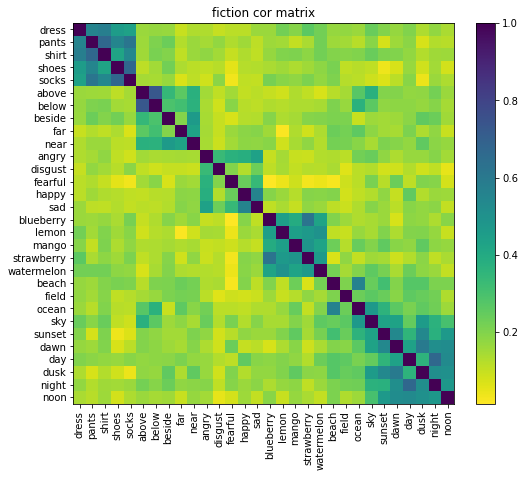

In [161]:
plt.figure(figsize=(10,7))
plt.imshow(cosine_similarity(fic_reps), cmap='viridis_r')
plt.yticks(ticks = range(30),labels = list(concept_list))
plt.xticks(ticks = range(30),labels = list(concept_list), rotation=90)
plt.title('fiction cor matrix')
cb = plt.colorbar(fraction=0.046, pad=0.04)

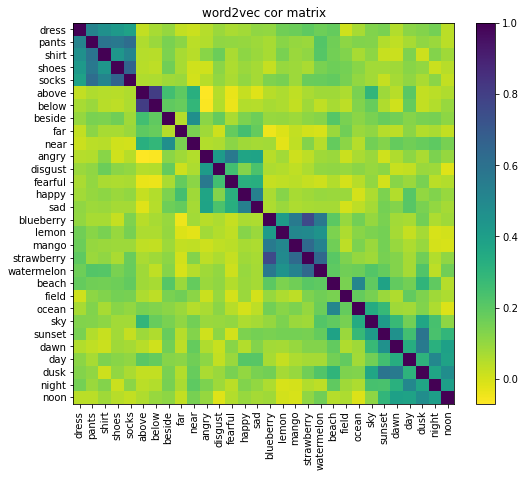

In [14]:
plt.figure(figsize=(10,7))
plt.imshow(np.corrcoef(w2v_reps), cmap= 'viridis_r')
plt.yticks(ticks = range(30),labels = list(concept_list))
plt.xticks(ticks = range(30),labels = list(concept_list), rotation=90)
plt.title('word2vec cor matrix')
cb = plt.colorbar(fraction=0.046, pad=0.04)

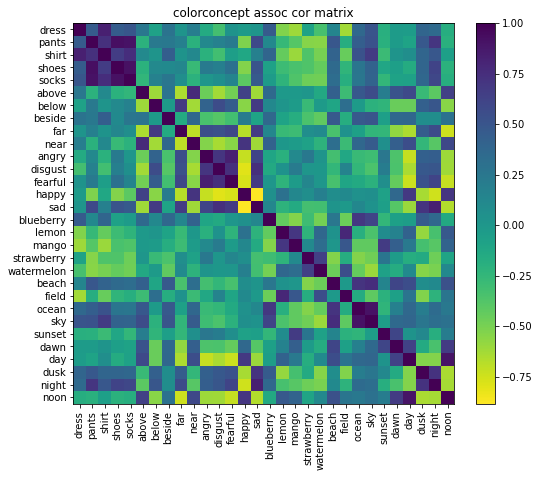

In [147]:
plt.figure(figsize=(10,7))
plt.imshow(np.corrcoef(ratings.iloc[:,1:]), cmap='viridis_r')
plt.yticks(ticks = range(30),labels = list(concept_list))
plt.xticks(ticks = range(30),labels = list(concept_list), rotation=90)
plt.title('colorconcept assoc cor matrix')
cb = plt.colorbar(fraction=0.046, pad=0.04)
plt.savefig('../plots/plot_with_bar.pdf', format='pdf')

In [16]:

w2v_df = pd.concat([pd.DataFrame(concept_list.reshape(30,1), columns = {'concepts'}),pd.DataFrame(w2v_reps)], axis=1)
fic_df = pd.concat([pd.DataFrame(concept_list.reshape(30,1), columns = {'concepts'}),pd.DataFrame(fic_reps)], axis=1)


In [17]:
c_means = pd.read_csv('../data/col_means.csv')

ratings_c = ratings.iloc[:,1:] - c_means.V1.values

In [18]:
u, s, vt = np.linalg.svd(ratings_c,full_matrices=False)

<BarContainer object of 30 artists>

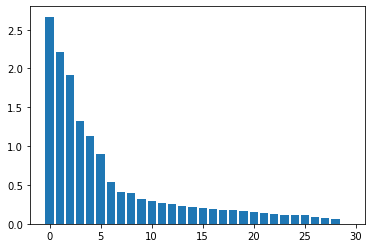

In [19]:
plt.bar(np.arange(len(s)),s)

In [20]:
s = np.diag(s)

In [21]:
#ratings = pd.concat([ratings, pd.DataFrame(u[:,:3]@s[:3,:3], columns = ['c1','c2','c3'])], axis=1)
#ratings = pd.concat([ratings, pd.DataFrame(u[:,:3], columns = ['c1','c2','c3'])], axis=1)

In [22]:
ratings_pc_df = pd.concat ( [pd.DataFrame({'concepts':concept_list,'c1':u[:,0],'c2':u[:,1],'c3':u[:,2]}), ratings_c],axis=1)


Text(0.5, 0.92, 'color-concept association space')

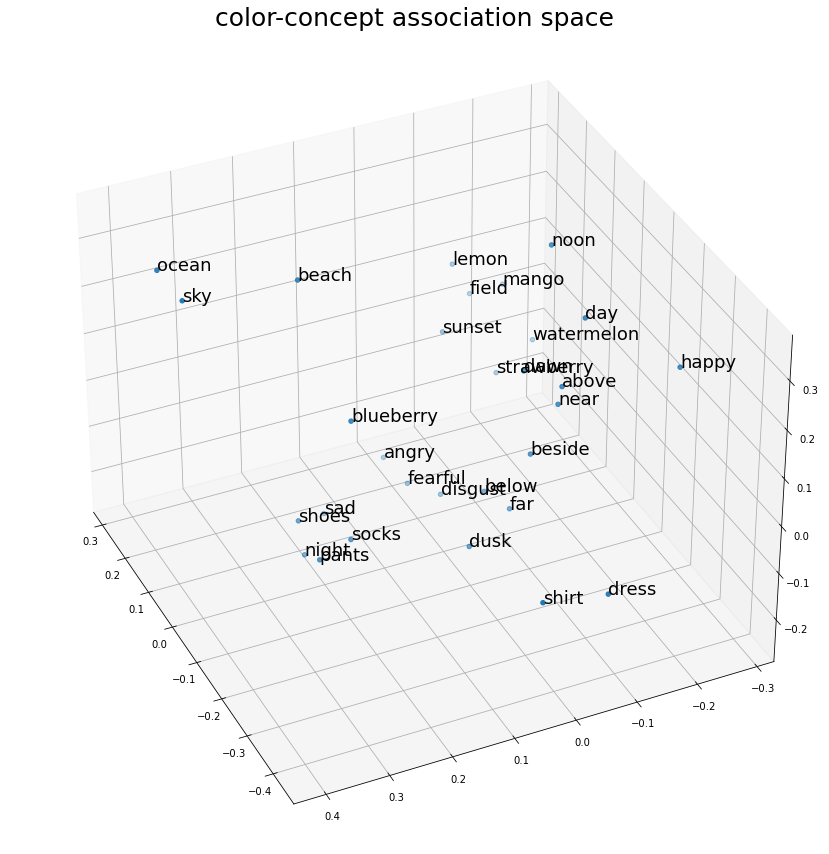

In [23]:
fig= plt.figure(figsize=(15,15))
ax = plt.axes(projection='3d')
ax.view_init(35, 155)
#sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

ax.scatter3D( ratings_pc_df['c1'], ratings_pc_df['c2'], ratings_pc_df['c3'])
for i, txt in enumerate(ratings_pc_df['concepts']):
    ax.text(ratings_pc_df['c1'].iloc[i],ratings_pc_df['c2'].iloc[i], ratings_pc_df['c3'].iloc[i], txt, fontsize=18)
plt.title('color-concept association space', fontsize=25)

In [24]:
w2v_reps_c = w2v_df.iloc[:,1:].apply(lambda x: x- x.mean())
w2v_reps_c_means = w2v_df.iloc[:,1:].mean(axis = 0).values



In [25]:
w2v_reps_c = w2v_reps_c.add_suffix('_w')


<BarContainer object of 30 artists>

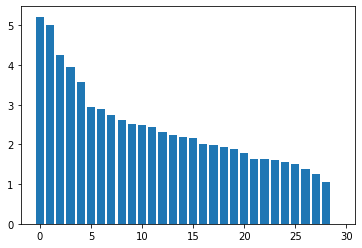

In [26]:
##plot the eigenvalues in a way that makes it clear that there's at least some low rank and a principled way to select the top few principal components
u_2, s_2, vt_2 = np.linalg.svd(w2v_reps_c,full_matrices=False)
plt.bar(np.arange(len(s_2)),s_2)

In [27]:
s_2 = np.diag(s_2)
#w2v_df = pd.concat([w2v_df, pd.DataFrame(u_2[:,:3]@s_2[:3,:3], columns = ['c1','c2','c3'])], axis=1)
#w2v_df = pd.concat([w2v_df, pd.DataFrame(u_2[:,:3], columns = ['c1','c2','c3'])], axis=1)

In [28]:
w2v_pc_df = pd.concat ( [pd.DataFrame({'concepts':concept_list,'c1':u_2[:,0],'c2':u_2[:,1],'c3':u_2[:,2]}), w2v_reps_c],axis=1)


Text(0.5, 0.92, 'word2vec space')

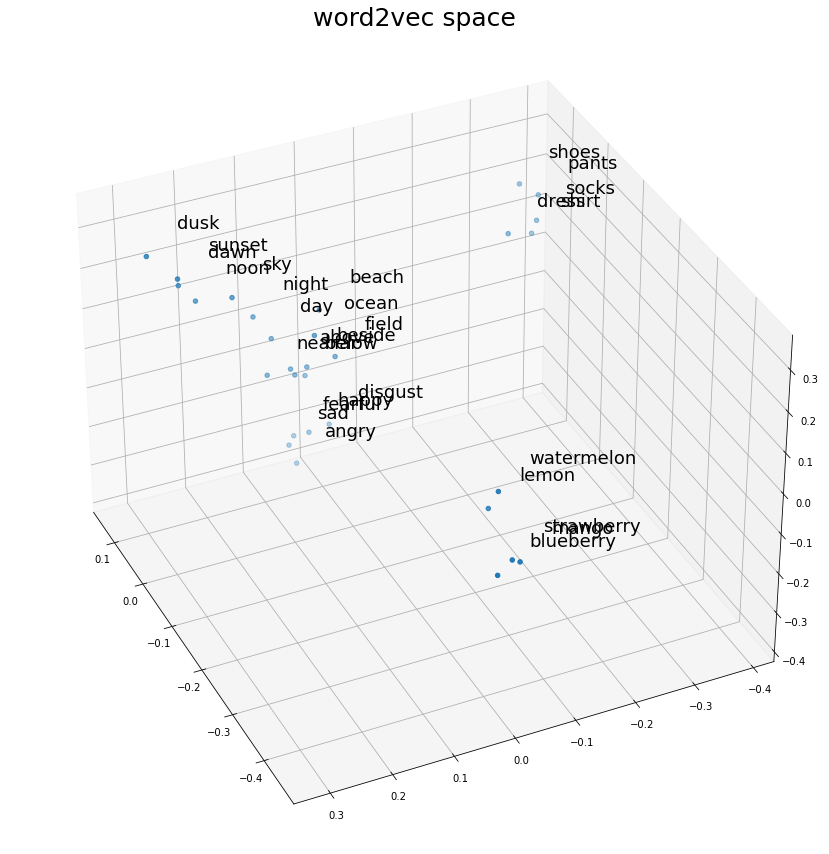

In [29]:
fig= plt.figure(figsize=(15,15))

ax = plt.axes(projection='3d')
ax.view_init(35, 155)
#sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

ax.scatter3D( w2v_pc_df['c1'], w2v_pc_df['c2'], w2v_pc_df['c3'])
for i, txt in enumerate(w2v_pc_df['concepts']):
    ax.text(w2v_pc_df['c1'].iloc[i],w2v_pc_df['c2'].iloc[i]-0.05, w2v_pc_df['c3'].iloc[i]+.05, txt, fontsize=18)
plt.title('word2vec space', fontsize=25)

In [30]:
fic_reps_c = fic_df.iloc[:,1:].apply(lambda x: x- x.mean())
fic_reps_c_means = fic_df.iloc[:,1:].mean(axis = 0).values

In [31]:
fic_reps_c = fic_reps_c.add_suffix('_f')


<BarContainer object of 30 artists>

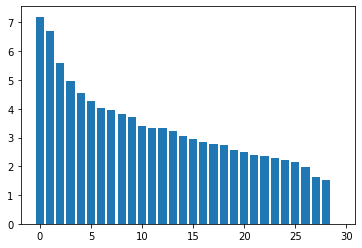

In [32]:
u_3, s_3, vt_3 = np.linalg.svd(fic_reps_c,full_matrices=False)
plt.bar(np.arange(len(s_3)),s_3)

In [33]:
fic_pc_df = pd.concat ( [pd.DataFrame({'concepts':concept_list,'c1':u_3[:,0],'c2':u_3[:,1],'c3':u_3[:,2]}), fic_reps_c],axis=1)


Text(0.5, 0.92, 'fiction embedding space')

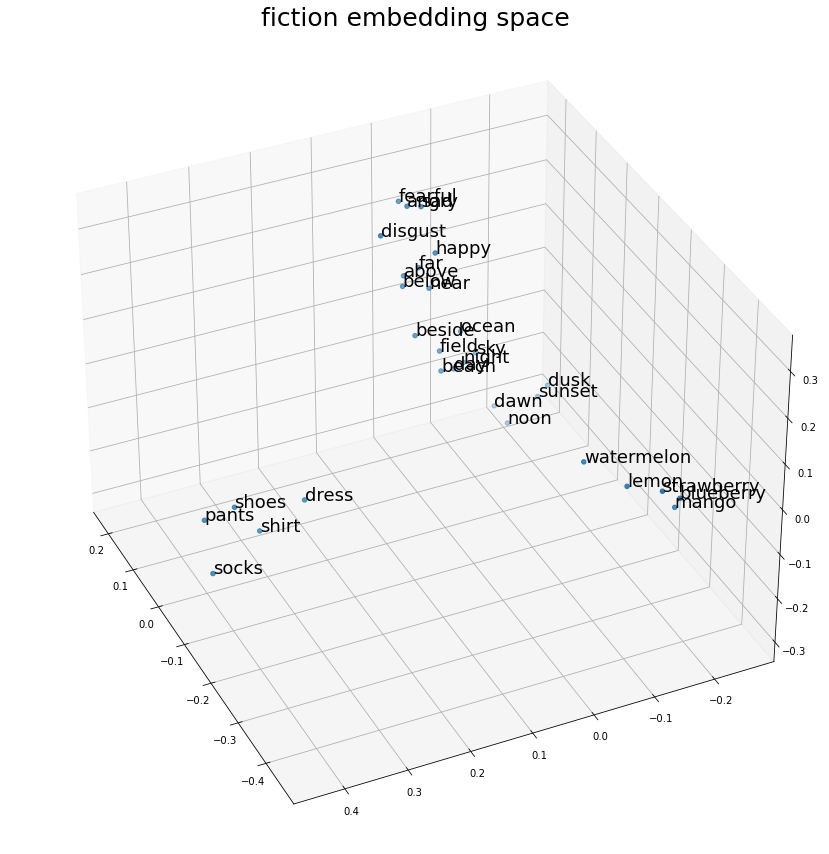

In [34]:
fig= plt.figure(figsize=(15,15))
ax = plt.axes(projection='3d')
ax.view_init(35, 155)
#sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

ax.scatter3D( fic_pc_df['c1'], fic_pc_df['c2'], fic_pc_df['c3'])
for i, txt in enumerate(fic_pc_df['concepts']):
    ax.text(fic_pc_df['c1'].iloc[i],fic_pc_df['c2'].iloc[i], fic_pc_df['c3'].iloc[i], txt, fontsize=18)
plt.title('fiction embedding space', fontsize=25)

In [35]:
reg_df = pd.concat([pd.Series(concept_list,name='concepts'),ratings_c,w2v_reps_c, fic_reps_c,ratings_pc_df[['c1','c2','c3']]],axis=1)

In [36]:
reg_df.shape

(30, 662)

In [37]:
reg_df.to_csv('../data/reg_df.csv',index=False)


In [38]:
pred_coords_w2v = pd.read_csv('../data/w2v_predicted_coords.csv')
pred_coords_fic = pd.read_csv('../data/fic_predicted_coords.csv')

Text(0.5, 0.92, 'Predicted coordinates w2v')

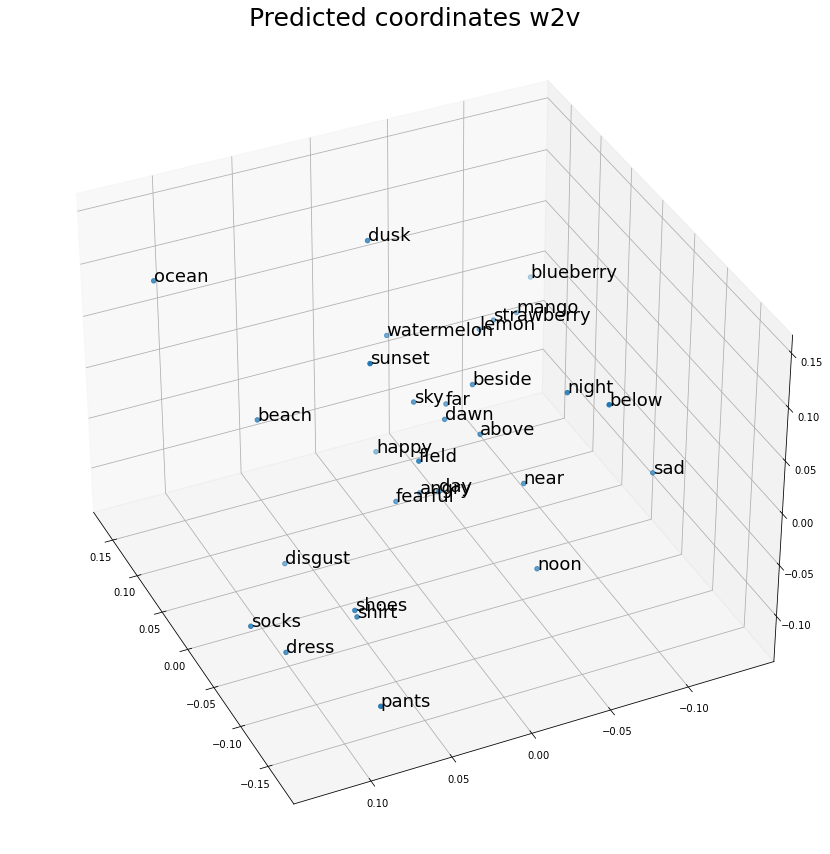

In [39]:
fig= plt.figure(figsize=(15,15))

ax = plt.axes(projection='3d')
#ax.view_init(30, 210)
ax.view_init(35, 155)
#sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

ax.scatter3D( pred_coords_w2v['c1_pred'], pred_coords_w2v['c2_pred'], pred_coords_w2v['c3_pred'])
for i, txt in enumerate(pred_coords_w2v['concepts']):
    ax.text(pred_coords_w2v['c1_pred'].iloc[i],pred_coords_w2v['c2_pred'].iloc[i], pred_coords_w2v['c3_pred'].iloc[i], txt, fontsize=18)
plt.title('Predicted coordinates w2v', fontsize=25)



Text(0.5, 0.92, 'Predicted coordinates fiction')

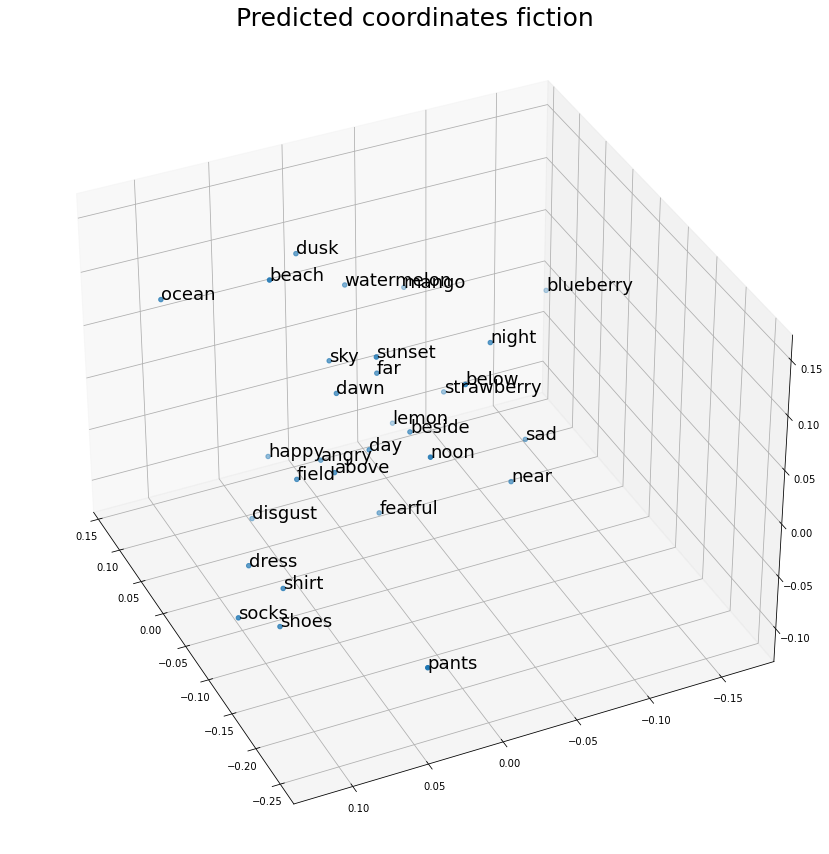

In [40]:
fig= plt.figure(figsize=(15,15))

ax = plt.axes(projection='3d')
#ax.view_init(30, 210)
ax.view_init(35, 155)
#sns.scatterplot(x='c2',y='c3',hue='concepts',data=w2v_df,legend =False)

ax.scatter3D( pred_coords_fic['c1_pred'], pred_coords_fic['c2_pred'], pred_coords_fic['c3_pred'])
for i, txt in enumerate(pred_coords_fic['concepts']):
    ax.text(pred_coords_fic['c1_pred'].iloc[i],pred_coords_fic['c2_pred'].iloc[i], pred_coords_fic['c3_pred'].iloc[i], txt, fontsize=18)
plt.title('Predicted coordinates fiction', fontsize=25)


vss2022

In [139]:
# cca_inds=[0]
# cca_inds.extend(range(4,58))
cca_df =pd.read_csv("../data/cc_assoc.csv") #color-concept association matrix
fic_df =pd.read_csv("../data/fic.csv") 	 #fiction word2vec
w2v_df =pd.read_csv("../data/w2v.csv")      #standard word2vec
col3d_df  =pd.read_csv("../data/color_salmon.csv") #salmon 3d embedding for color triplets
kind3d_df =pd.read_csv("../data/kind_salmon.csv") #salmon 3d embedding for kind triplets
sym3d_df  =pd.read_csv("../data/symbolic_salmon.csv") #salmon 3d embedding for symbol triplets
uw_58_cdict = pd.read_csv("../data/color_dict_uw58.csv") 
# cdict= read.csv("../data/color_dict_uw58.csv")

In [140]:
import colorsys

def hex_to_rgb(hex_str):
    
    """Returns a tuple representing the given hex string as RGB.
    
    >>> hex_to_rgb('CC0000')
    (204, 0, 0)
    """
    if hex_str.startswith('#'):
        hex_str = hex_str[1:]
    return tuple([int(hex_str[i:i + 2], 16) for i in range(0, len(hex_str), 2)])

uw_58_cdict['hue_angle'] = uw_58_cdict.apply( lambda x: colorsys.rgb_to_hls(*list( hex_to_rgb(x.hex)))[0], axis=1)
uw_58_cdict['saturation'] = uw_58_cdict.apply( lambda x: colorsys.rgb_to_hls(*list( hex_to_rgb(x.hex)))[1], axis=1)
uw_58_cdict['lightness'] = uw_58_cdict.apply( lambda x: colorsys.rgb_to_hls(*list( hex_to_rgb(x.hex)))[2], axis=1)


In [141]:
uw_58_cdict
uw_58_cdict = uw_58_cdict.sort_values(by=['hue_angle','saturation'],ascending=[True,False]).reset_index(drop=True)
sorted_col_order = uw_58_cdict['index'].values
sorted_col_order = np.delete(sorted_col_order,2)
sorted_col_order = np.concatenate((sorted_col_order,[54]))
sorted_col_order
uw_58_cdict= uw_58_cdict.sort_values(by='index')

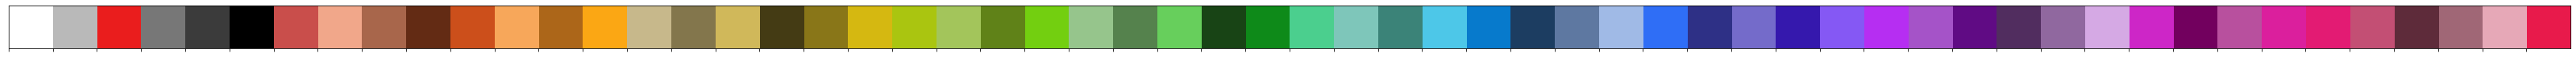

In [51]:
sns.palplot(uw_58_cdict.sort_values(by=['hue_angle','saturation'],ascending=[True,False]).hex.tolist())

In [167]:
from sklearn.decomposition import PCA
pca_cca = PCA(n_components=3, svd_solver='full')
pca_cca.fit(cca_df.iloc[:,4:].T)


pca_w2v= PCA( n_components=3, svd_solver='full')
pca_w2v.fit(w2v_df.iloc[:,4:].T)


pca_fic = PCA( n_components=3, svd_solver='full')
pca_fic.fit(fic_df.iloc[:,4:].T)

PCA(n_components=3, svd_solver='full')

In [414]:
import statsmodels.api as sm

### Models

In [436]:
X  = np.vstack([pca_fic.components_,pca_cca.components_]).T
y_1 = col3d_df.iloc[:,1]
y_2 = col3d_df.iloc[:,2]
y_3 = col3d_df.iloc[:,3]

_X = sm.add_constant(X)
#_Z = sm.add_constant(Z)
model_c1 = sm.OLS(y_1, _X).fit()
model_c2 = sm.OLS(y_2, _X).fit()
model_c3 = sm.OLS(y_3, _X).fit()

In [437]:
model_c1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     d1   R-squared:                       0.787
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     14.16
Date:                Thu, 05 May 2022   Prob (F-statistic):           1.03e-06
Time:                        17:42:16   Log-Likelihood:                 35.522
No. Observations:                  30   AIC:                            -57.04
Df Residuals:                      23   BIC:                            -47.24
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0045      0.015      0.293      0.772      -0.027       0.036
x1            -0.4328      0.093     -4.649      0.000      -0.625      -0.240
x2             0.3908      0.119      3.294      0.003       0.145       0.636
x3             0.4583      0.099      4.648      0.000       0.254       0.662
x4            -0.0120      0.110     -0.110      0.914      -0.239       0.215
x5            -0.3452      0.096     -3.599      0.002      -0.544      -0.147
x6            -0.2475      0.106     -2.339      0.028      -0.466      -0.029
==============================================================================
Omnibus:                        1.960   Durbin-Watson:                   1.471
Prob(Omnibus):                  0.375   Jarque-Bera (JB):                1.483
Skew:                          -0.351   Prob(JB):                        0.476
Kurtosis:                       2.167   Cond. No.                         10.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

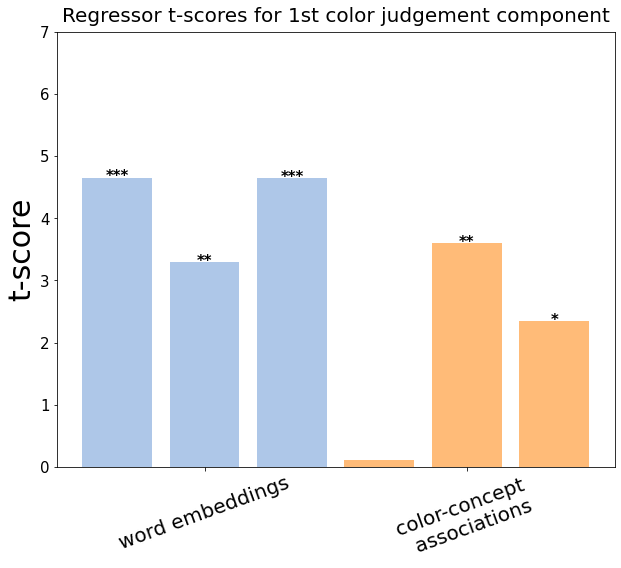

In [438]:
from itertools import repeat

plt.figure(figsize=(10,8))
t_cmap = plt.get_cmap("tab20")

l = [list((t_cmap.colors[1],)*3),list((t_cmap.colors[3],)*3),list((t_cmap.colors[5],)*3),list((t_cmap.colors[7],)*3)]
t_colors = [item for sublist in l for item in sublist]




bar = plt.bar(np.arange(len(model_c1.tvalues[1:])),np.abs(model_c1.tvalues[1:]),color=t_colors)

for i,rect in enumerate(bar):
    if model_c1.pvalues[i+1]<0.001:
        annot = '***'
    elif model_c1.pvalues[i+1]<0.01:
        annot = '**'
    elif model_c1.pvalues[i+1]<0.05:
        annot = '*'
    else:
        annot=''
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height-0.10, f'{annot}', ha='center', va='bottom', fontsize=15, fontweight='bold')

plt.xticks(np.arange(1,6,3),['word embeddings','color-concept \n associations'], fontsize=20, rotation=20)
plt.ylim(0,7)
plt.ylabel('t-score', fontsize=30)
plt.xlabel('')
plt.yticks(fontsize=15)
plt.title('Regressor t-scores for 1st color judgement component', fontsize=20,pad=10)
#plt.savefig('reg1.pdf',bbox_inches='tight')
plt.savefig('../plots/color1.pdf',format='pdf',bbox_inches='tight')

In [439]:
model_c2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     d2   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     9.269
Date:                Thu, 05 May 2022   Prob (F-statistic):           3.28e-05
Time:                        17:42:16   Log-Likelihood:                 32.559
No. Observations:                  30   AIC:                            -51.12
Df Residuals:                      23   BIC:                            -41.31
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0045      0.017      0.264      0.794      -0.031       0.040
x1            -0.0722      0.103     -0.702      0.490      -0.285       0.140
x2            -0.5171      0.131     -3.949      0.001      -0.788      -0.246
x3            -0.1557      0.109     -1.430      0.166      -0.381       0.069
x4            -0.2936      0.121     -2.421      0.024      -0.544      -0.043
x5             0.1537      0.106      1.452      0.160      -0.065       0.373
x6             0.1211      0.117      1.037      0.310      -0.120       0.363
==============================================================================
Omnibus:                        0.626   Durbin-Watson:                   2.459
Prob(Omnibus):                  0.731   Jarque-Bera (JB):                0.229
Skew:                          -0.213   Prob(JB):                        0.892
Kurtosis:                       3.037   Cond. No.                         10.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

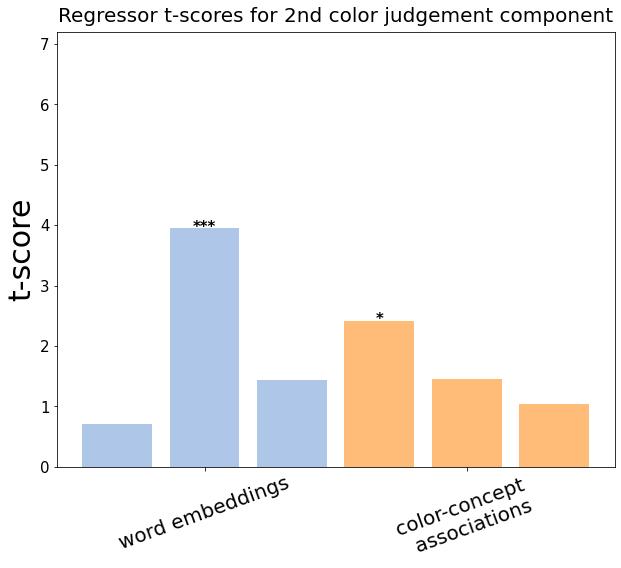

In [440]:
from itertools import repeat

plt.figure(figsize=(10,8))
t_cmap = plt.get_cmap("tab20")

l = [list((t_cmap.colors[1],)*3),list((t_cmap.colors[3],)*3),list((t_cmap.colors[5],)*3),list((t_cmap.colors[7],)*3)]
t_colors = [item for sublist in l for item in sublist]




bar = plt.bar(np.arange(len(model_c2.tvalues[1:])),np.abs(model_c2.tvalues[1:]),color=t_colors)

for i,rect in enumerate(bar):
    if model_c2.pvalues[i+1]<0.001:
        annot = '***'
    elif model_c2.pvalues[i+1]<0.01:
        annot = '**'
    elif model_c2.pvalues[i+1]<0.05:
        annot = '*'
    else:
        annot=''
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height-0.10, f'{annot}', ha='center', va='bottom', fontsize=15, fontweight='bold')

plt.xticks(np.arange(1,6,3),['word embeddings','color-concept \n associations'], fontsize=20, rotation=20)
plt.ylim(0,7.2)
plt.ylabel('t-score', fontsize=30)
plt.xlabel('')
plt.yticks(fontsize=15)
plt.title('Regressor t-scores for 2nd color judgement component', fontsize=20,pad=10)
#plt.savefig('reg1.pdf',bbox_inches='tight')
plt.savefig('../plots/color2.pdf',format='pdf',bbox_inches='tight')

In [441]:
model_c3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     d3   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     7.768
Date:                Thu, 05 May 2022   Prob (F-statistic):           0.000121
Time:                        17:42:17   Log-Likelihood:                 26.918
No. Observations:                  30   AIC:                            -39.84
Df Residuals:                      23   BIC:                            -30.03
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0052      0.021      0.251      0.804      -0.037       0.048
x1            -0.1077      0.124     -0.868      0.394      -0.364       0.149
x2             0.1164      0.158      0.737      0.469      -0.210       0.443
x3             0.1790      0.131      1.363      0.186      -0.093       0.451
x4            -0.5158      0.146     -3.525      0.002      -0.818      -0.213
x5            -0.5649      0.128     -4.420      0.000      -0.829      -0.301
x6            -0.1537      0.141     -1.090      0.287      -0.445       0.138
==============================================================================
Omnibus:                        0.663   Durbin-Watson:                   1.814
Prob(Omnibus):                  0.718   Jarque-Bera (JB):                0.693
Skew:                           0.108   Prob(JB):                        0.707
Kurtosis:                       2.287   Cond. No.                         10.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

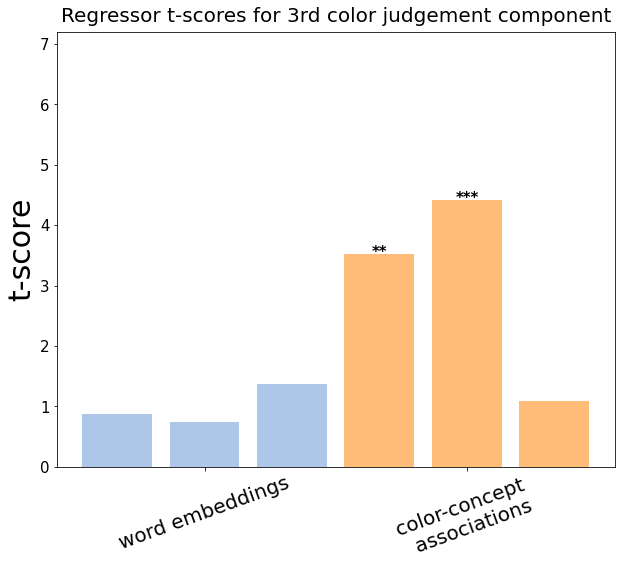

In [442]:
from itertools import repeat

plt.figure(figsize=(10,8))
t_cmap = plt.get_cmap("tab20")

l = [list((t_cmap.colors[1],)*3),list((t_cmap.colors[3],)*3),list((t_cmap.colors[5],)*3),list((t_cmap.colors[7],)*3)]
t_colors = [item for sublist in l for item in sublist]




bar = plt.bar(np.arange(len(model_c3.tvalues[1:])),np.abs(model_c3.tvalues[1:]),color=t_colors)

for i,rect in enumerate(bar):
    if model_c3.pvalues[i+1]<0.001:
        annot = '***'
    elif model_c3.pvalues[i+1]<0.01:
        annot = '**'
    elif model_c3.pvalues[i+1]<0.05:
        annot = '*'
    else:
        annot=''
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height-0.10, f'{annot}', ha='center', va='bottom', fontsize=15, fontweight='bold')

plt.xticks(np.arange(1,6,3),['word embeddings','color-concept \n associations'], fontsize=20, rotation=20)
plt.ylim(0,7.2)
plt.ylabel('t-score', fontsize=30)
plt.xlabel('')
plt.yticks(fontsize=15)
plt.title('Regressor t-scores for 3rd color judgement component', fontsize=20,pad=10)
#plt.savefig('reg1.pdf',bbox_inches='tight')
plt.savefig('../plots/color3.pdf',format='pdf',bbox_inches='tight')

In [443]:
X = np.vstack([pca_fic.components_,pca_cca.components_]).T
y_1 = kind3d_df.iloc[:,1]
y_2 = kind3d_df.iloc[:,2]
y_3 = kind3d_df.iloc[:,3]

_X = sm.add_constant(X)
#_Z = sm.add_constant(Z)
model_c1 = sm.OLS(y_1, _X).fit()
model_c2 = sm.OLS(y_2, _X).fit()
model_c3 = sm.OLS(y_3, _X).fit()

In [444]:
model_c1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     d1   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     15.07
Date:                Thu, 05 May 2022   Prob (F-statistic):           6.00e-07
Time:                        17:42:18   Log-Likelihood:                 33.076
No. Observations:                  30   AIC:                            -52.15
Df Residuals:                      23   BIC:                            -42.34
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0047      0.017     -0.278      0.783      -0.039       0.030
x1             0.4984      0.101      4.935      0.000       0.289       0.707
x2             0.7666      0.129      5.957      0.000       0.500       1.033
x3             0.4065      0.107      3.800      0.001       0.185       0.628
x4            -0.0841      0.119     -0.706      0.487      -0.331       0.162
x5            -0.0027      0.104     -0.026      0.980      -0.218       0.213
x6            -0.1980      0.115     -1.725      0.098      -0.435       0.039
==============================================================================
Omnibus:                        2.259   Durbin-Watson:                   1.473
Prob(Omnibus):                  0.323   Jarque-Bera (JB):                1.096
Skew:                          -0.391   Prob(JB):                        0.578
Kurtosis:                       3.515   Cond. No.                         10.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

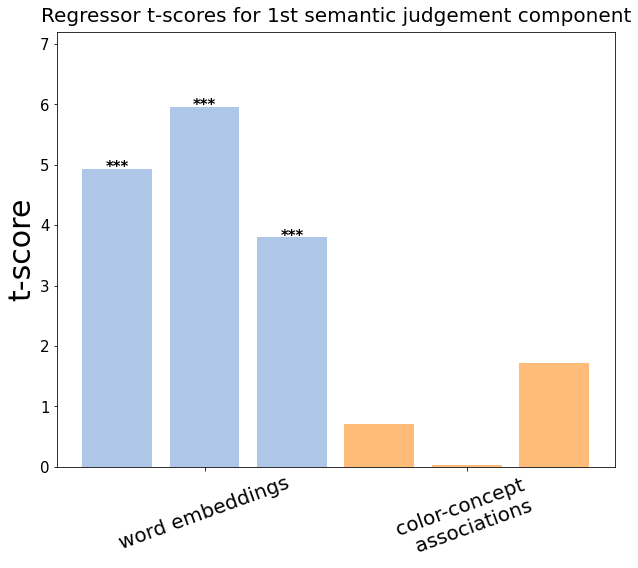

In [445]:
from itertools import repeat

plt.figure(figsize=(10,8))
t_cmap = plt.get_cmap("tab20")

l = [list((t_cmap.colors[1],)*3),list((t_cmap.colors[3],)*3),list((t_cmap.colors[5],)*3),list((t_cmap.colors[7],)*3)]
t_colors = [item for sublist in l for item in sublist]




bar = plt.bar(np.arange(len(model_c1.tvalues[1:])),np.abs(model_c1.tvalues[1:]),color=t_colors)

for i,rect in enumerate(bar):
    if model_c1.pvalues[i+1]<0.001:
        annot = '***'
    elif model_c1.pvalues[i+1]<0.01:
        annot = '**'
    elif model_c1.pvalues[i+1]<0.05:
        annot = '*'
    else:
        annot=''
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height-0.10, f'{annot}', ha='center', va='bottom', fontsize=15, fontweight='bold')

plt.xticks(np.arange(1,6,3),['word embeddings','color-concept \n associations'], fontsize=20, rotation=20)
plt.ylim(0,7.2)
plt.ylabel('t-score', fontsize=30)
plt.xlabel('')
plt.yticks(fontsize=15)
plt.title('Regressor t-scores for 1st semantic judgement component', fontsize=20,pad=10)
#plt.savefig('reg1.pdf',bbox_inches='tight')
plt.savefig('../plots/kind1.pdf',format='pdf',bbox_inches='tight')

In [446]:
model_c2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     d2   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     23.52
Date:                Thu, 05 May 2022   Prob (F-statistic):           9.83e-09
Time:                        17:42:18   Log-Likelihood:                 41.617
No. Observations:                  30   AIC:                            -69.23
Df Residuals:                      23   BIC:                            -59.42
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0030      0.013      0.237      0.814      -0.023       0.029
x1             0.3626      0.076      4.772      0.000       0.205       0.520
x2             0.5844      0.097      6.037      0.000       0.384       0.785
x3            -0.2268      0.080     -2.818      0.010      -0.393      -0.060
x4            -0.0973      0.090     -1.085      0.289      -0.283       0.088
x5             0.2621      0.078      3.348      0.003       0.100       0.424
x6             0.0005      0.086      0.005      0.996      -0.178       0.179
==============================================================================
Omnibus:                        0.532   Durbin-Watson:                   1.668
Prob(Omnibus):                  0.766   Jarque-Bera (JB):                0.474
Skew:                           0.278   Prob(JB):                        0.789
Kurtosis:                       2.734   Cond. No.                         10.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

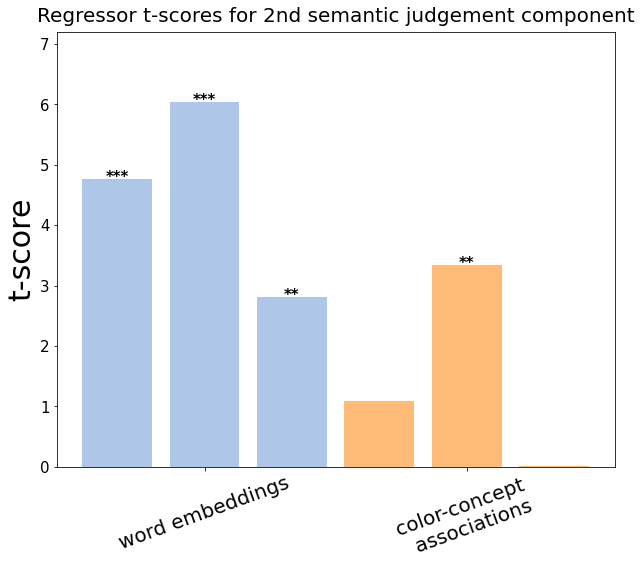

In [447]:
from itertools import repeat

plt.figure(figsize=(10,8))
t_cmap = plt.get_cmap("tab20")

l = [list((t_cmap.colors[1],)*3),list((t_cmap.colors[3],)*3),list((t_cmap.colors[5],)*3),list((t_cmap.colors[7],)*3)]
t_colors = [item for sublist in l for item in sublist]




bar = plt.bar(np.arange(len(model_c2.tvalues[1:])),np.abs(model_c2.tvalues[1:]),color=t_colors)

for i,rect in enumerate(bar):
    if model_c2.pvalues[i+1]<0.001:
        annot = '***'
    elif model_c2.pvalues[i+1]<0.01:
        annot = '**'
    elif model_c2.pvalues[i+1]<0.05:
        annot = '*'
    else:
        annot=''
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height-0.10, f'{annot}', ha='center', va='bottom', fontsize=15, fontweight='bold')

plt.xticks(np.arange(1,6,3),['word embeddings','color-concept \n associations'], fontsize=20, rotation=20)
plt.ylim(0,7.2)
plt.ylabel('t-score', fontsize=30)
plt.xlabel('')
plt.yticks(fontsize=15)
plt.title('Regressor t-scores for 2nd semantic judgement component', fontsize=20,pad=10)
#plt.savefig('reg1.pdf',bbox_inches='tight')
plt.savefig('../plots/kind2.pdf',format='pdf',bbox_inches='tight')

In [448]:
model_c3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     d3   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     16.62
Date:                Thu, 05 May 2022   Prob (F-statistic):           2.51e-07
Time:                        17:42:19   Log-Likelihood:                 35.756
No. Observations:                  30   AIC:                            -57.51
Df Residuals:                      23   BIC:                            -47.70
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0023      0.015      0.152      0.880      -0.029       0.034
x1            -0.6443      0.092     -6.975      0.000      -0.835      -0.453
x2             0.0672      0.118      0.571      0.573      -0.176       0.311
x3             0.3081      0.098      3.149      0.004       0.106       0.511
x4            -0.0641      0.109     -0.589      0.562      -0.290       0.161
x5            -0.3578      0.095     -3.759      0.001      -0.555      -0.161
x6            -0.1577      0.105     -1.502      0.147      -0.375       0.059
==============================================================================
Omnibus:                        0.808   Durbin-Watson:                   2.032
Prob(Omnibus):                  0.668   Jarque-Bera (JB):                0.475
Skew:                           0.306   Prob(JB):                        0.789
Kurtosis:                       2.935   Cond. No.                         10.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

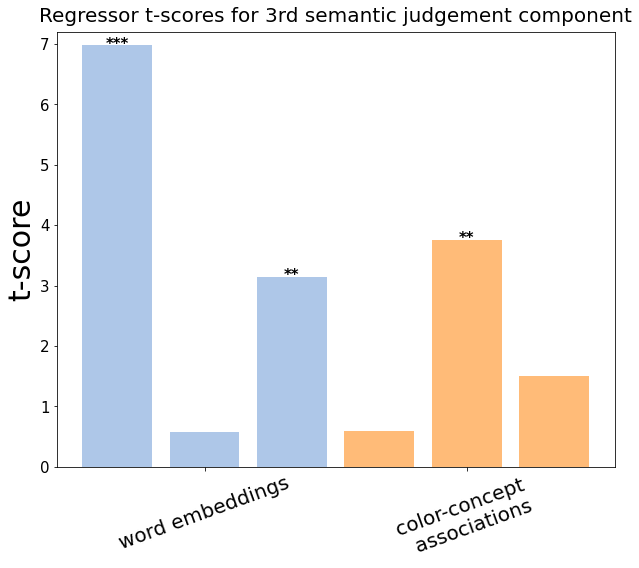

In [449]:
from itertools import repeat

plt.figure(figsize=(10,8))
t_cmap = plt.get_cmap("tab20")

l = [list((t_cmap.colors[1],)*3),list((t_cmap.colors[3],)*3),list((t_cmap.colors[5],)*3),list((t_cmap.colors[7],)*3)]
t_colors = [item for sublist in l for item in sublist]




bar = plt.bar(np.arange(len(model_c3.tvalues[1:])),np.abs(model_c3.tvalues[1:]),color=t_colors)

for i,rect in enumerate(bar):
    if model_c3.pvalues[i+1]<0.001:
        annot = '***'
    elif model_c3.pvalues[i+1]<0.01:
        annot = '**'
    elif model_c3.pvalues[i+1]<0.05:
        annot = '*'
    else:
        annot=''
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height-0.10, f'{annot}', ha='center', va='bottom', fontsize=15, fontweight='bold')

plt.xticks(np.arange(1,6,3),['word embeddings','color-concept \n associations'], fontsize=20, rotation=20)
plt.ylim(0,7.2)
plt.ylabel('t-score', fontsize=30)
plt.xlabel('')
plt.yticks(fontsize=15)
plt.title('Regressor t-scores for 3rd semantic judgement component', fontsize=20,pad=10)
#plt.savefig('reg1.pdf',bbox_inches='tight')
plt.savefig('../plots/kind3.pdf',format='pdf',bbox_inches='tight')

In [450]:
X = np.vstack([pca_fic.components_,pca_cca.components_]).T
y_1 = sym3d_df.iloc[:,1]
y_2 = sym3d_df.iloc[:,2]
y_3 = sym3d_df.iloc[:,3]

_X = sm.add_constant(X)
#_Z = sm.add_constant(Z)
model_c1 = sm.OLS(y_1, _X).fit()
model_c2 = sm.OLS(y_2, _X).fit()
model_c3 = sm.OLS(y_3, _X).fit()

In [451]:
model_c1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     d1   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     18.44
Date:                Thu, 05 May 2022   Prob (F-statistic):           9.75e-08
Time:                        17:42:20   Log-Likelihood:                 29.434
No. Observations:                  30   AIC:                            -44.87
Df Residuals:                      23   BIC:                            -35.06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0030      0.019      0.158      0.876      -0.036       0.042
x1            -0.6135      0.114     -5.379      0.000      -0.849      -0.378
x2             0.7775      0.145      5.351      0.000       0.477       1.078
x3             0.4807      0.121      3.980      0.001       0.231       0.731
x4            -0.0876      0.135     -0.651      0.521      -0.366       0.191
x5            -0.3457      0.118     -2.942      0.007      -0.589      -0.103
x6             0.0027      0.130      0.021      0.984      -0.265       0.271
==============================================================================
Omnibus:                        2.442   Durbin-Watson:                   1.297
Prob(Omnibus):                  0.295   Jarque-Bera (JB):                1.248
Skew:                          -0.112   Prob(JB):                        0.536
Kurtosis:                       3.974   Cond. No.                         10.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

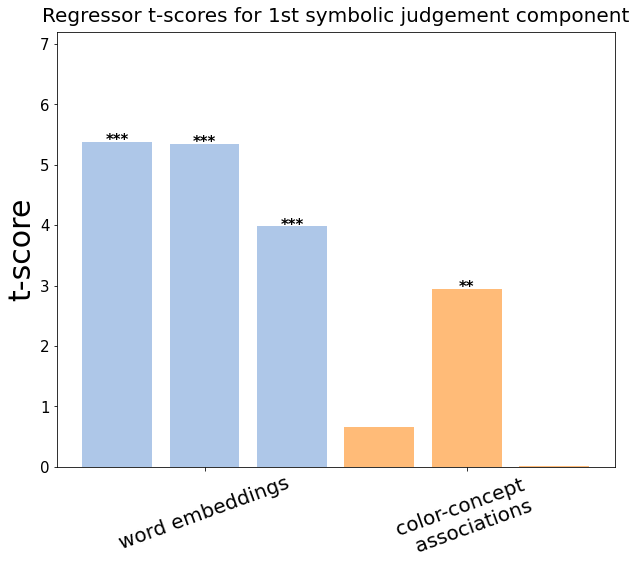

In [452]:

plt.figure(figsize=(10,8))
t_cmap = plt.get_cmap("tab20")

l = [list((t_cmap.colors[1],)*3),list((t_cmap.colors[3],)*3),list((t_cmap.colors[5],)*3),list((t_cmap.colors[7],)*3)]
t_colors = [item for sublist in l for item in sublist]




bar = plt.bar(np.arange(len(model_c1.tvalues[1:])),np.abs(model_c1.tvalues[1:]),color=t_colors)

for i,rect in enumerate(bar):
    if model_c1.pvalues[i+1]<0.001:
        annot = '***'
    elif model_c1.pvalues[i+1]<0.01:
        annot = '**'
    elif model_c1.pvalues[i+1]<0.05:
        annot = '*'
    else:
        annot=''
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height-0.10, f'{annot}', ha='center', va='bottom', fontsize=15, fontweight='bold')

plt.xticks(np.arange(1,6,3),['word embeddings','color-concept \n associations'], fontsize=20, rotation=20)
plt.ylim(0,7.2)
plt.ylabel('t-score', fontsize=30)
plt.xlabel('')
plt.yticks(fontsize=15)
plt.title('Regressor t-scores for 1st symbolic judgement component', fontsize=20,pad=10)
#plt.savefig('reg1.pdf',bbox_inches='tight')
plt.savefig('../plots/sym1.pdf',format='pdf',bbox_inches='tight')

In [453]:
model_c2.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     d2   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     16.37
Date:                Thu, 05 May 2022   Prob (F-statistic):           2.88e-07
Time:                        17:42:20   Log-Likelihood:                 28.249
No. Observations:                  30   AIC:                            -42.50
Df Residuals:                      23   BIC:                            -32.69
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0177      0.020      0.900      0.377      -0.023       0.058
x1            -0.3598      0.119     -3.032      0.006      -0.605      -0.114
x2            -0.8927      0.151     -5.906      0.000      -1.205      -0.580
x3            -0.6167      0.126     -4.908      0.000      -0.877      -0.357
x4             0.0131      0.140      0.093      0.926      -0.276       0.303
x5             0.2503      0.122      2.048      0.052      -0.003       0.503
x6             0.1661      0.135      1.232      0.231      -0.113       0.445
==============================================================================
Omnibus:                        3.180   Durbin-Watson:                   1.139
Prob(Omnibus):                  0.204   Jarque-Bera (JB):                1.912
Skew:                          -0.581   Prob(JB):                        0.384
Kurtosis:                       3.425   Cond. No.                         10.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

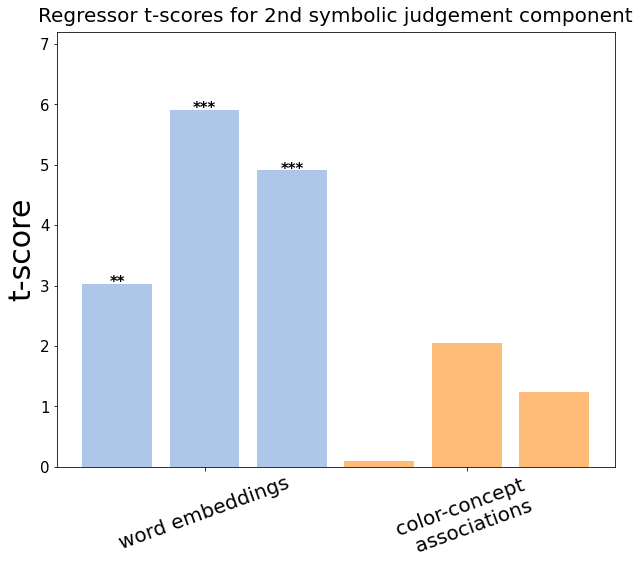

In [454]:

plt.figure(figsize=(10,8))
t_cmap = plt.get_cmap("tab20")

l = [list((t_cmap.colors[1],)*3),list((t_cmap.colors[3],)*3),list((t_cmap.colors[5],)*3),list((t_cmap.colors[7],)*3)]
t_colors = [item for sublist in l for item in sublist]




bar = plt.bar(np.arange(len(model_c2.tvalues[1:])),np.abs(model_c2.tvalues[1:]),color=t_colors)

for i,rect in enumerate(bar):
    if model_c2.pvalues[i+1]<0.001:
        annot = '***'
    elif model_c2.pvalues[i+1]<0.01:
        annot = '**'
    elif model_c2.pvalues[i+1]<0.05:
        annot = '*'
    else:
        annot=''
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height-0.10, f'{annot}', ha='center', va='bottom', fontsize=15, fontweight='bold')

plt.xticks(np.arange(1,6,3),['word embeddings','color-concept \n associations'], fontsize=20, rotation=20)
plt.ylim(0,7.2)
plt.ylabel('t-score', fontsize=30)
plt.xlabel('')
plt.yticks(fontsize=15)
plt.title('Regressor t-scores for 2nd symbolic judgement component', fontsize=20,pad=10)
#plt.savefig('reg1.pdf',bbox_inches='tight')
plt.savefig('../plots/sym2.pdf',format='pdf',bbox_inches='tight')

In [455]:
model_c3.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     d3   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     19.78
Date:                Thu, 05 May 2022   Prob (F-statistic):           5.08e-08
Time:                        17:42:21   Log-Likelihood:                 26.852
No. Observations:                  30   AIC:                            -39.70
Df Residuals:                      23   BIC:                            -29.90
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0139      0.021     -0.673      0.507      -0.057       0.029
x1            -0.9068      0.124     -7.296      0.000      -1.164      -0.650
x2            -0.4874      0.158     -3.078      0.005      -0.815      -0.160
x3             0.3234      0.132      2.457      0.022       0.051       0.596
x4            -0.0652      0.147     -0.445      0.661      -0.369       0.238
x5            -0.4110      0.128     -3.209      0.004      -0.676      -0.146
x6             0.2136      0.141      1.512      0.144      -0.079       0.506
==============================================================================
Omnibus:                        0.983   Durbin-Watson:                   1.581
Prob(Omnibus):                  0.612   Jarque-Bera (JB):                0.213
Skew:                           0.097   Prob(JB):                        0.899
Kurtosis:                       3.364   Cond. No.                         10.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

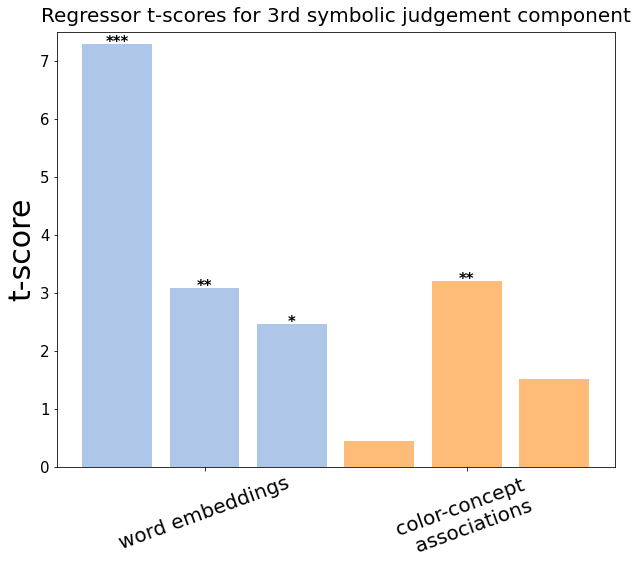

In [456]:

plt.figure(figsize=(10,8))
t_cmap = plt.get_cmap("tab20")

l = [list((t_cmap.colors[1],)*3),list((t_cmap.colors[3],)*3),list((t_cmap.colors[5],)*3),list((t_cmap.colors[7],)*3)]
t_colors = [item for sublist in l for item in sublist]




bar = plt.bar(np.arange(len(model_c3.tvalues[1:])),np.abs(model_c3.tvalues[1:]),color=t_colors)

for i,rect in enumerate(bar):
    if model_c3.pvalues[i+1]<0.001:
        annot = '***'
    elif model_c3.pvalues[i+1]<0.01:
        annot = '**'
    elif model_c3.pvalues[i+1]<0.05:
        annot = '*'
    else:
        annot=''
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2.0, height-0.10, f'{annot}', ha='center', va='bottom', fontsize=15, fontweight='bold')

plt.xticks(np.arange(1,6,3),['word embeddings','color-concept \n associations'], fontsize=20, rotation=20)
plt.ylim(0,7.5)
plt.ylabel('t-score', fontsize=30)
plt.xlabel('')
plt.yticks(fontsize=15)
plt.title('Regressor t-scores for 3rd symbolic judgement component', fontsize=20,pad=10)
#plt.savefig('reg1.pdf',bbox_inches='tight')
plt.savefig('../plots/sym3.pdf',format='pdf',bbox_inches='tight')

In [240]:
scipy.spatial.distance.squareform(scipy.spatial.distance.pdist(cca_df.iloc[:,4:], metric='cosine')).

(30, 30)

## plotting

In [274]:
cca_df.iloc[0,4:].sort_values(ascending=False).values


array([0.297090122040085, 0.286332330212661, 0.2507347249233819,
       0.220645805522522, 0.2180009596966059, 0.2086170465549369,
       0.20763222156306, 0.2068816756652669, 0.206698203951499,
       0.2030975342018749, 0.2014183502578729, 0.1966673557525589,
       0.1886557229694129, 0.188555329810352, 0.188364645995669,
       0.188137740791395, 0.183069699532291, 0.1785052157831679,
       0.1745594599395289, 0.168434539494817, 0.1662034561846219,
       0.165779968837809, 0.163392190901901, 0.161270759434402,
       0.155099895542476, 0.151421877968516, 0.149839356200918,
       0.147668822299548, 0.141387043232864, 0.138990071659034,
       0.1322826538798969, 0.128432907277021, 0.124118662793171,
       0.123921771116199, 0.121427078609396, 0.1213622641608889,
       0.1204665949570159, 0.1184084675055159, 0.1182122085031089,
       0.117868219861034, 0.103688787503589, 0.101530525648705,
       0.1004344631078489, 0.0921407587497399, 0.0920093790322349,
       0.0918972675358

In [52]:
cca_df

,concepts,c1,c2,c3,V1,V2,V3,V4,V5,V6,...,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58
0,dress,-0.420792,0.075494,-0.093040,0.101531,0.161271,0.123922,0.132283,0.206882,0.188656,...,0.009721,0.121427,0.013261,0.050018,0.066933,0.124119,0.027069,0.044734,0.118408,0.054902
1,pants,-0.107621,-0.251770,-0.135802,-0.000709,0.202365,0.087307,0.034418,-0.019837,-0.012959,...,-0.010904,0.023094,-0.051687,-0.042221,-0.093484,-0.108694,-0.077723,-0.090943,-0.082477,-0.086139
2,shirt,-0.425963,-0.033225,-0.066546,0.140437,0.191687,0.165641,0.218689,0.169330,0.174697,...,0.006231,0.124448,0.019771,0.059185,0.036933,0.101514,0.027017,0.007078,0.016221,0.006361
3,shoes,0.018999,-0.233742,-0.152197,-0.062949,0.061062,-0.017849,-0.004436,-0.053431,-0.057073,...,-0.062884,-0.048469,-0.067573,-0.065555,-0.109005,0.019535,-0.087254,-0.116568,-0.102321,-0.116139
4,socks,-0.075121,-0.187125,-0.139878,-0.054147,0.022312,0.011734,0.060720,0.031882,-0.007021,...,-0.018144,-0.043729,-0.004917,-0.092065,-0.106296,-0.089215,-0.048868,-0.052922,-0.066748,-0.066504
5,above,-0.165441,0.117560,0.143554,0.142068,-0.017296,0.085860,0.088875,0.022426,0.043340,...,0.005729,0.109472,0.016642,0.086448,0.081872,0.114226,0.088420,0.094356,0.105951,0.099664
6,below,-0.035443,0.051994,-0.150335,-0.054908,0.001832,0.009930,-0.057811,0.133530,0.040723,...,0.081427,0.020809,0.077514,0.012727,0.029896,-0.050076,-0.051580,0.057263,-0.073119,-0.034232
7,beside,-0.140702,0.079153,-0.003064,0.067417,-0.000668,0.044232,0.077015,0.069693,0.098049,...,0.007590,0.022728,0.054956,0.035692,0.064082,0.051203,0.039117,0.037903,0.041939,0.050826
8,far,-0.083601,0.072607,-0.160555,-0.038339,0.041134,0.000918,-0.022636,0.111670,0.095607,...,0.035439,-0.035528,0.037573,0.012552,0.024372,0.019924,0.024001,0.020810,-0.060735,-0.018476
9,near,-0.150735,0.118749,0.095759,0.119161,-0.014389,0.018941,0.022655,0.010449,0.048863,...,0.001950,0.076216,0.005887,0.052494,0.087454,0.065564,0.129350,0.097786,0.080893,0.077629


In [72]:
sorted_col_order
uw_58_cdict.hex.values

array(['#0e8a19', '#ac6619', '#608218', '#96c58c', '#443b14', '#a0bae6',
       '#cc4f1b', '#b9b9b9', '#7ec6ba', '#3518ad', '#a8664b', '#1c3d61',
       '#c7b88b', '#83764c', '#aac510', '#67cf5c', '#600b84', '#b62ef2',
       '#a3c55b', '#55824d', '#777777', '#5e2b3a', '#d5a9e4', '#897618',
       '#fba714', '#73cf10', '#e6a8b7', '#5e78a1', '#2e3086', '#632b14',
       '#90689f', '#f7a75a', '#cd26c7', '#e81a4b', '#ea1d1d', '#4bcf8e',
       '#746bca', '#512d5f', '#a06776', '#ffffff', '#72005e', '#077acc',
       '#db1f9d', '#d0b85a', '#3b8378', '#000000', '#f1a78a', '#c34f74',
       '#b8509e', '#e31b73', '#8558f4', '#a553c8', '#d5b811', '#4dc7e8',
       '#2f6ef6', '#184415', '#3b3b3b', '#c94e4b'], dtype=object)

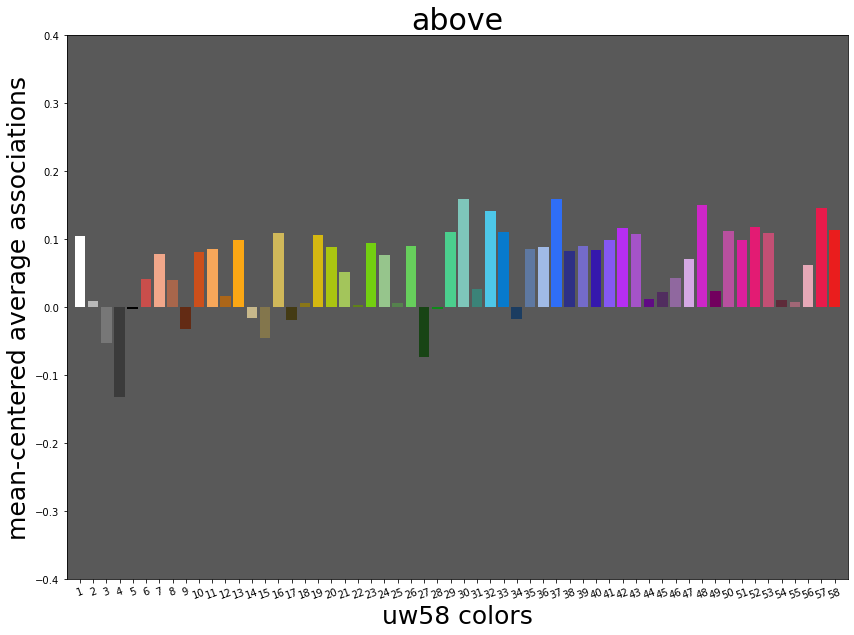

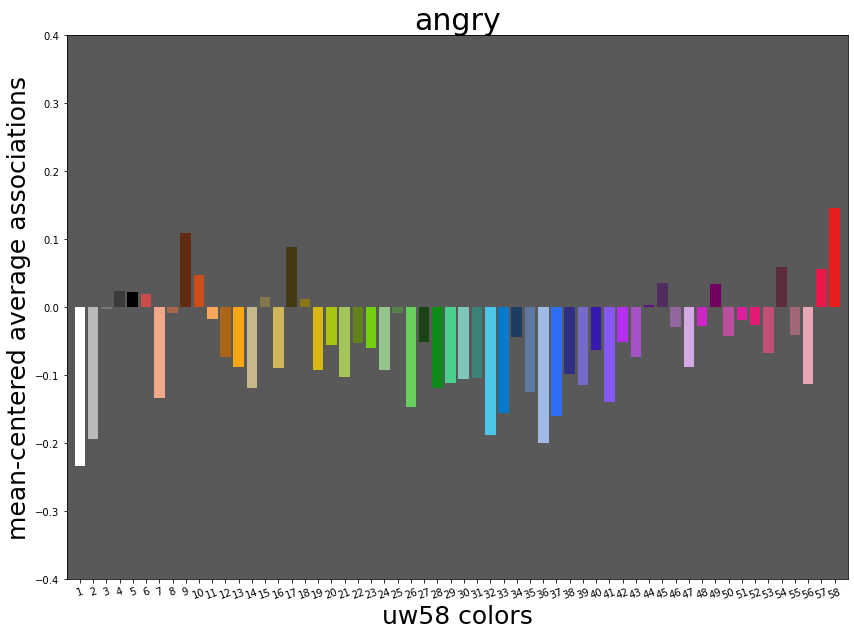

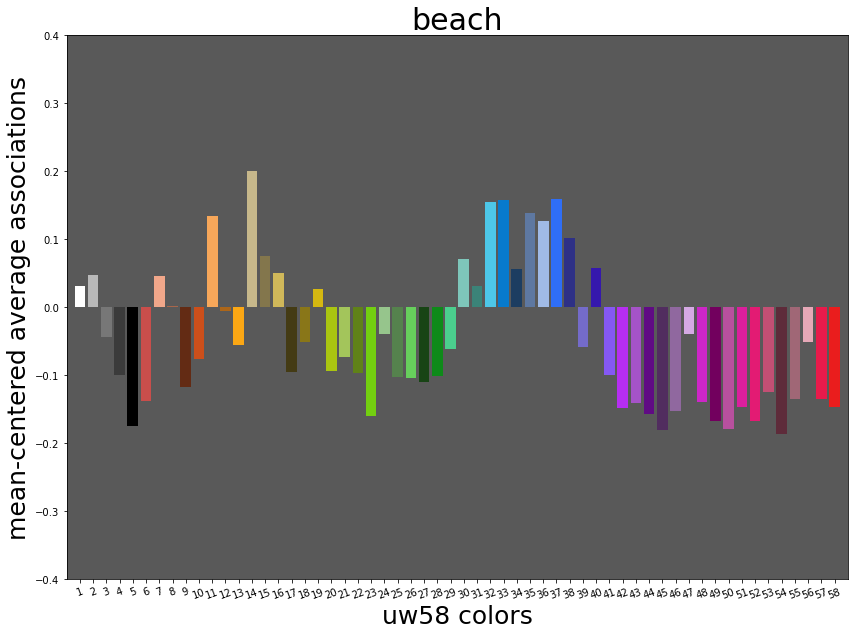

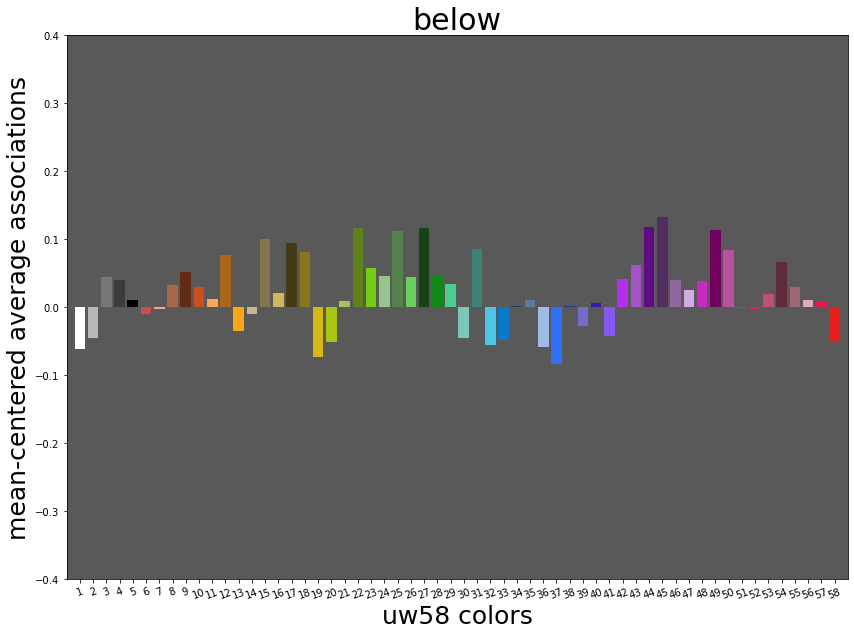

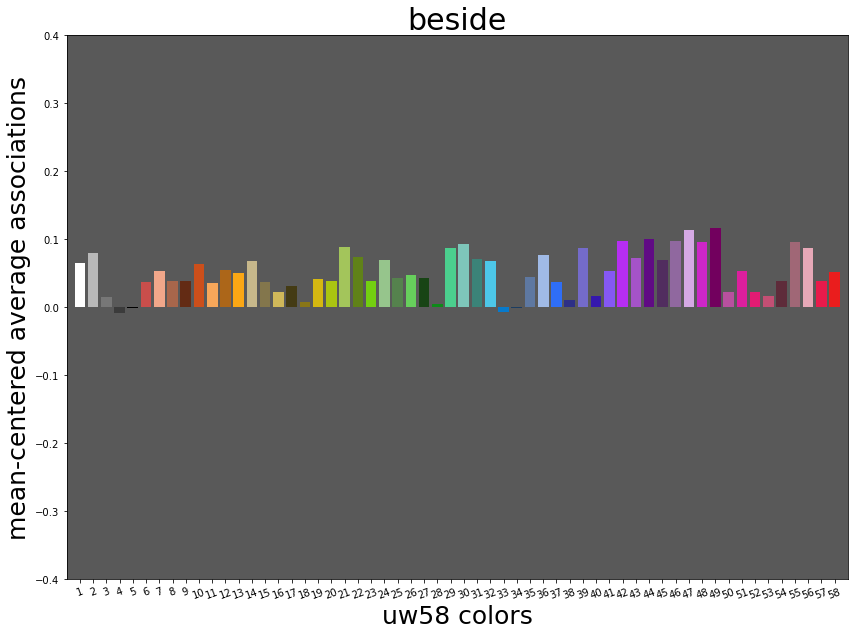

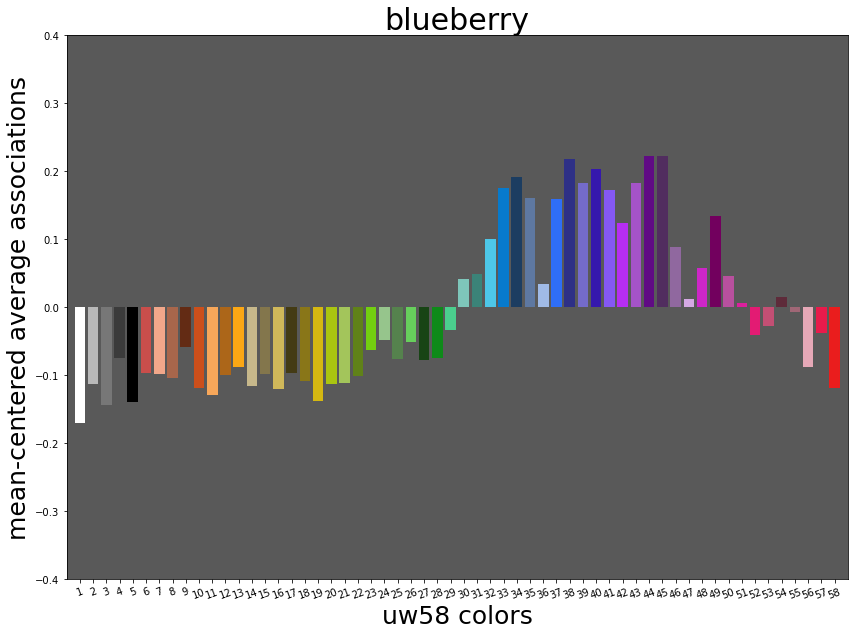

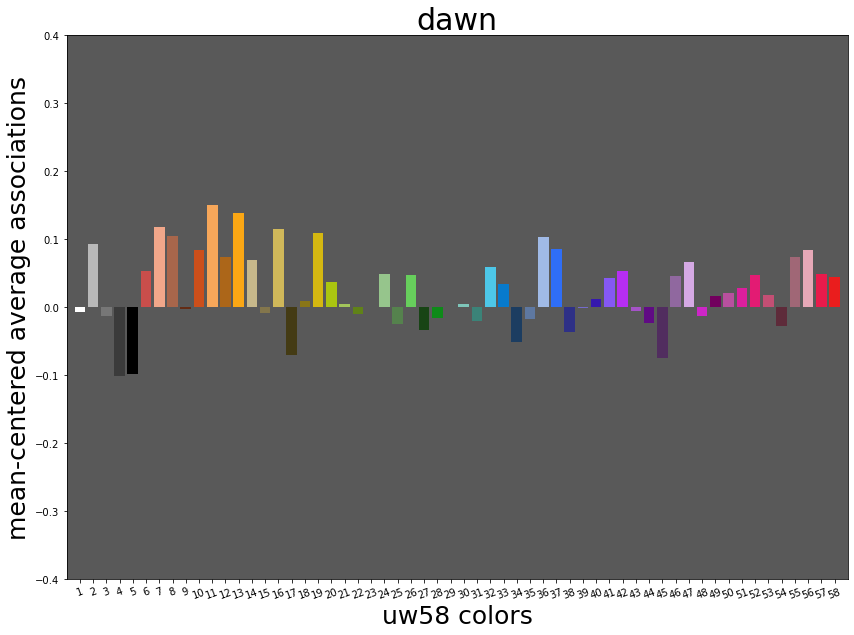

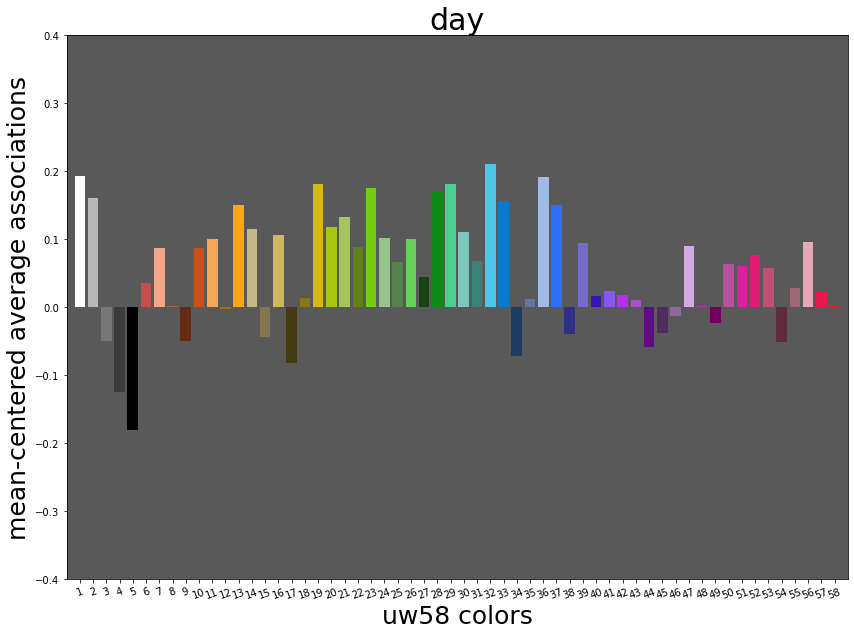

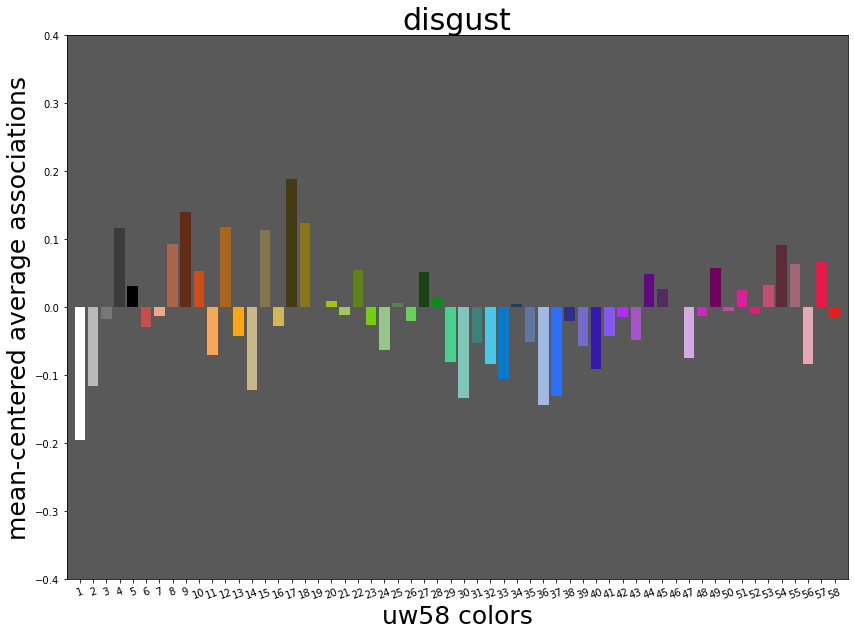

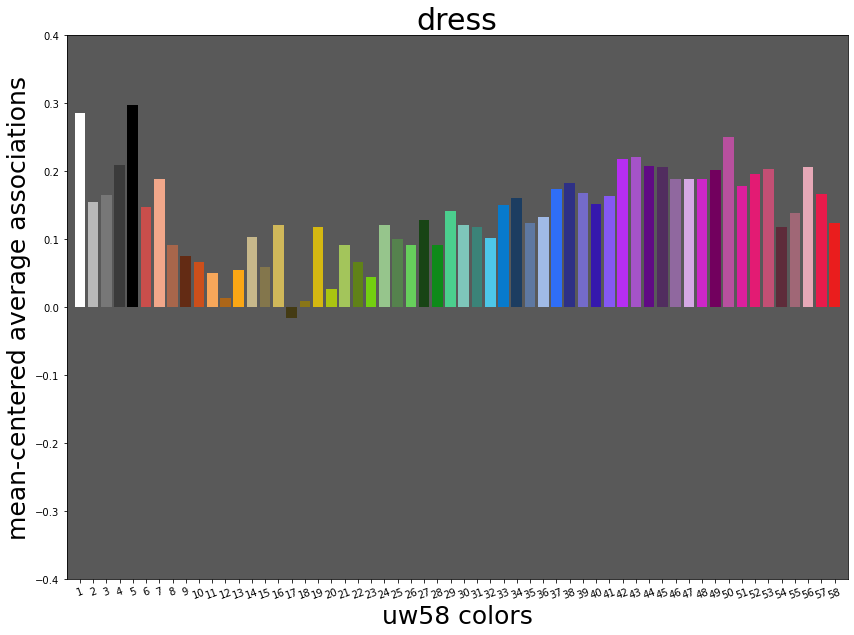

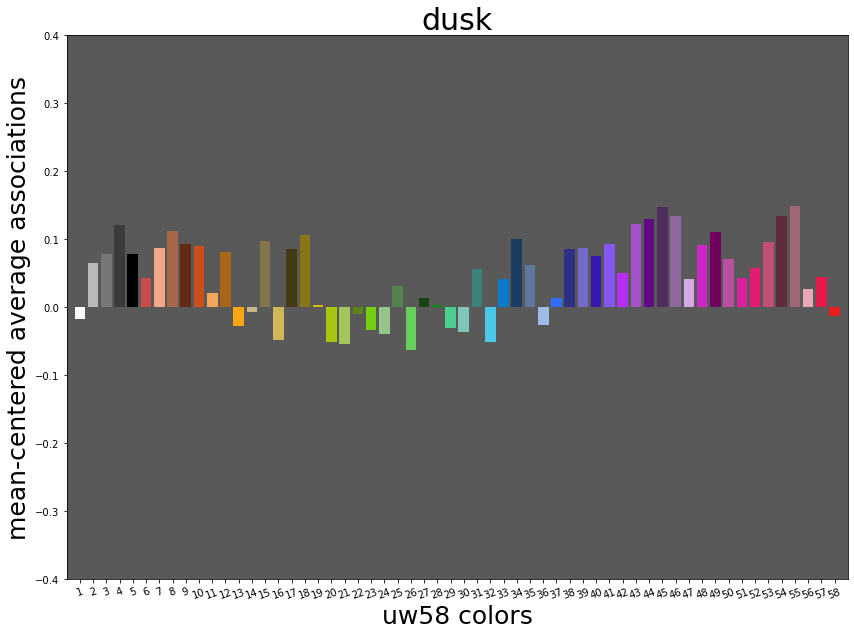

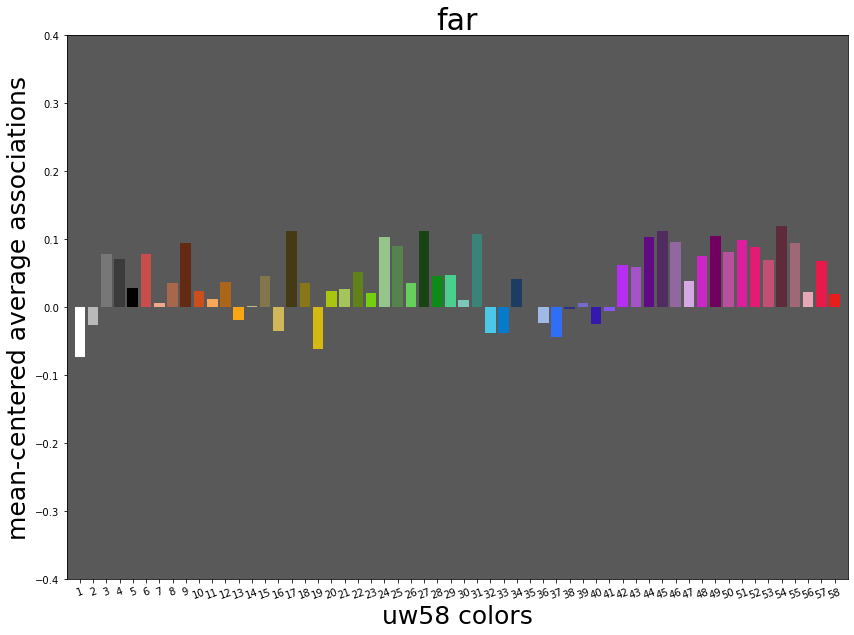

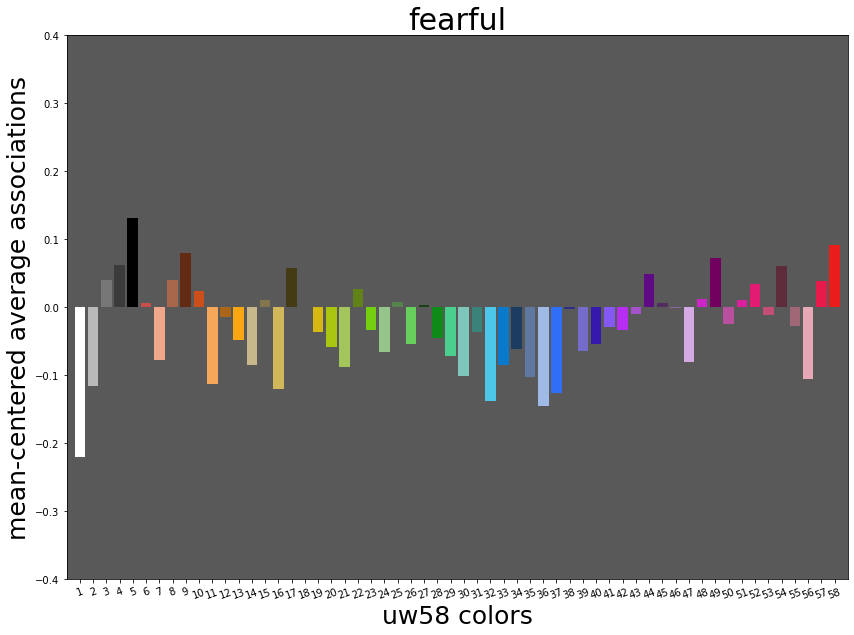

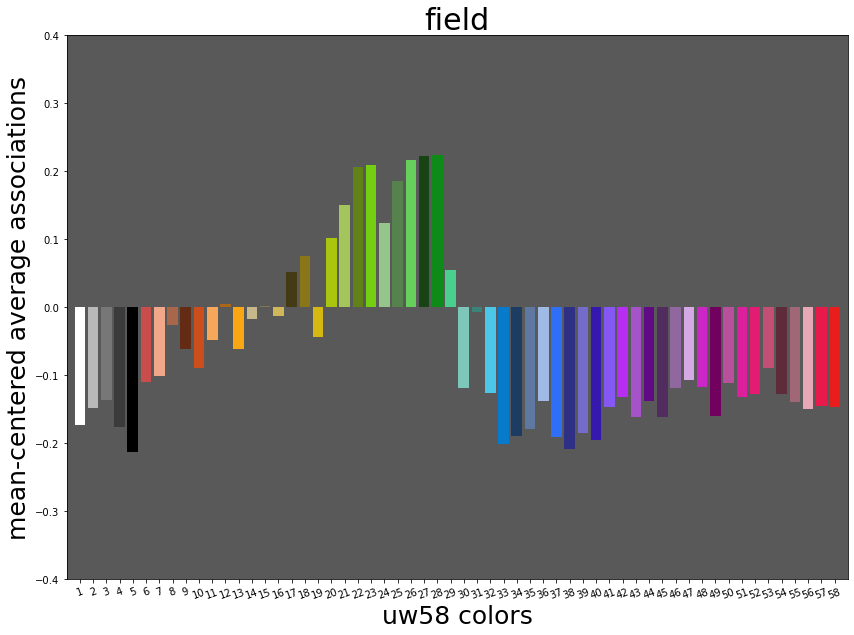

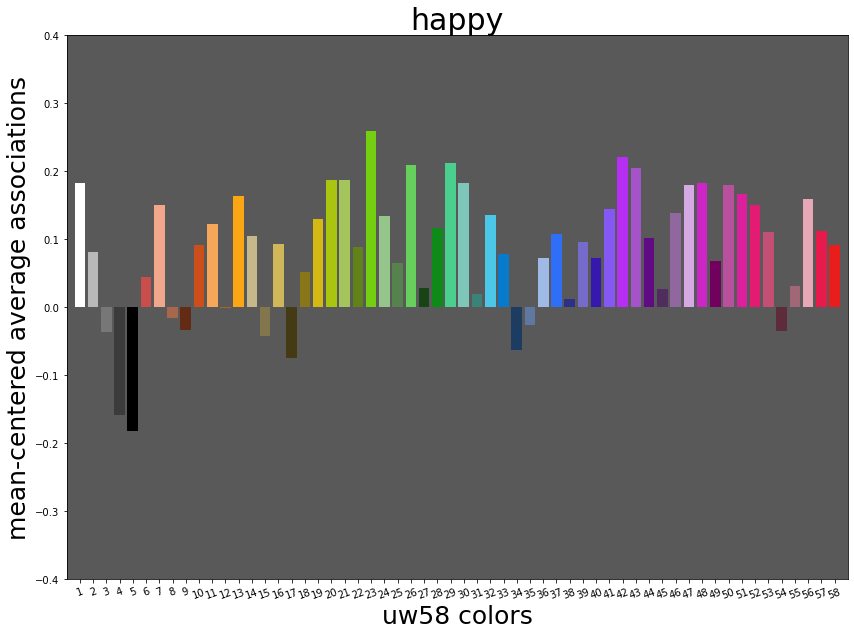

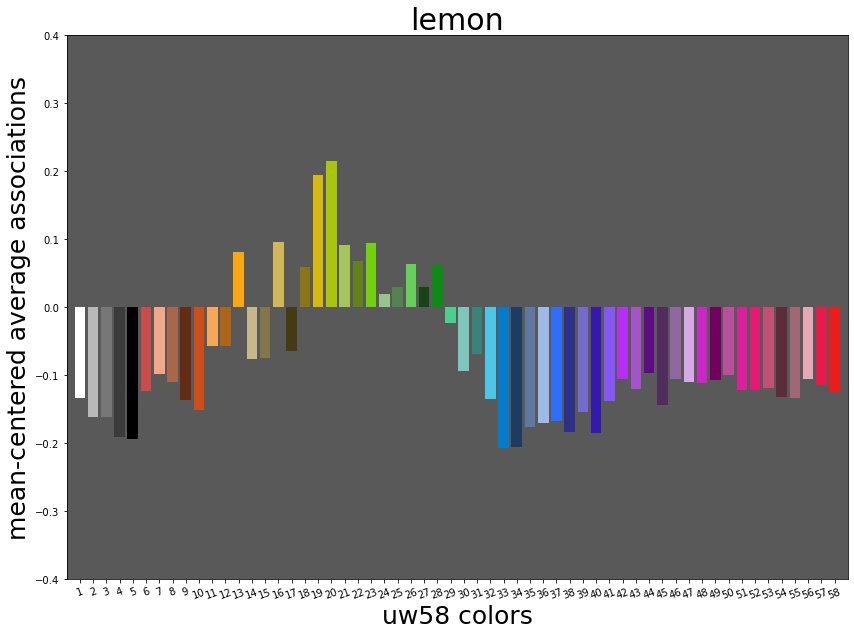

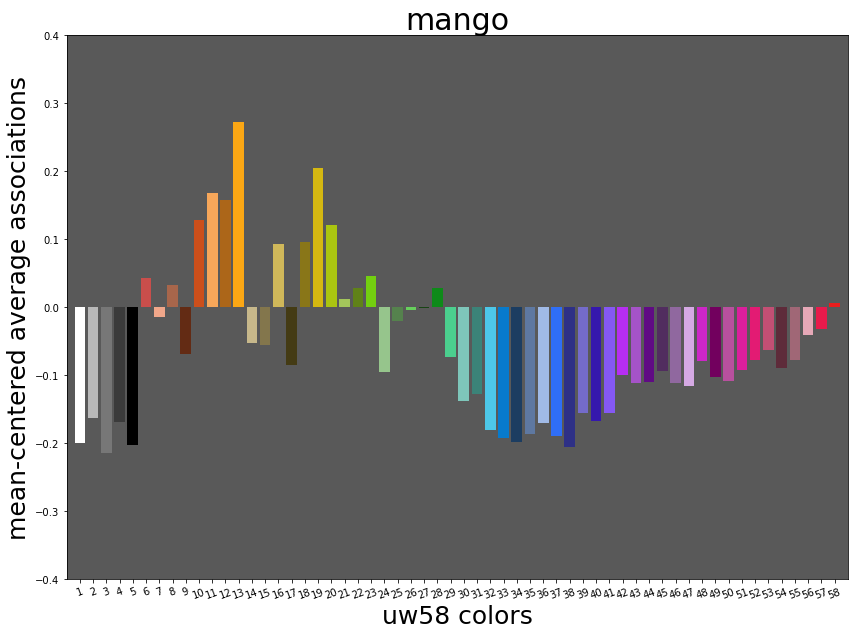

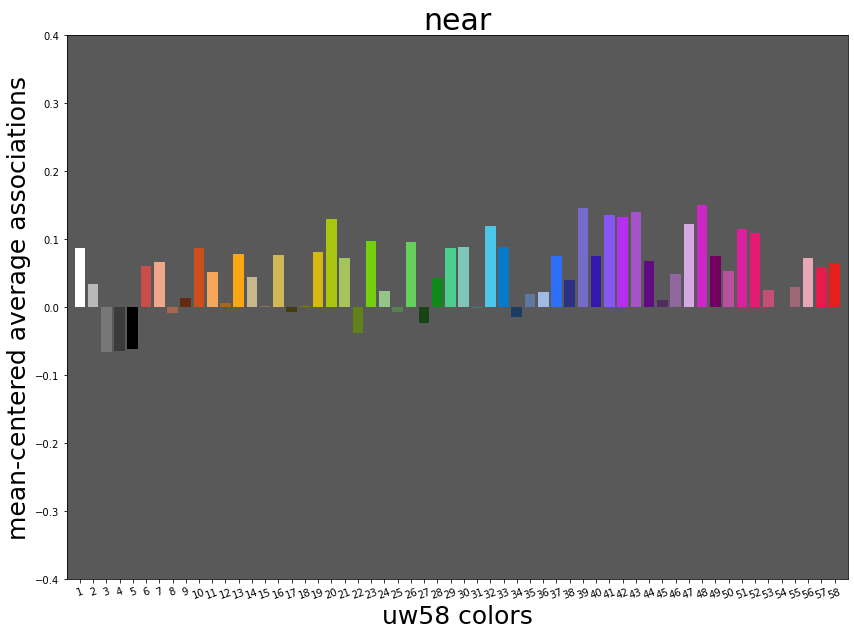

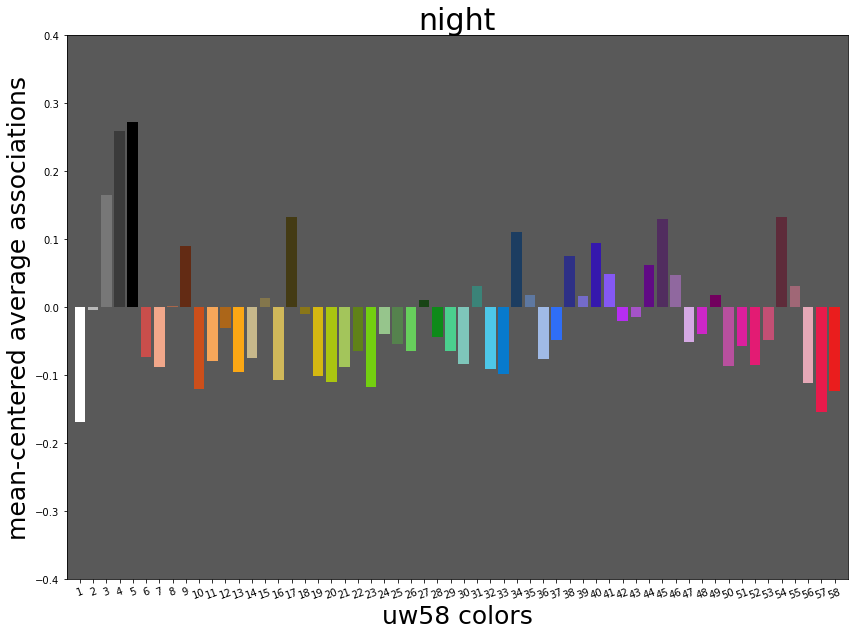

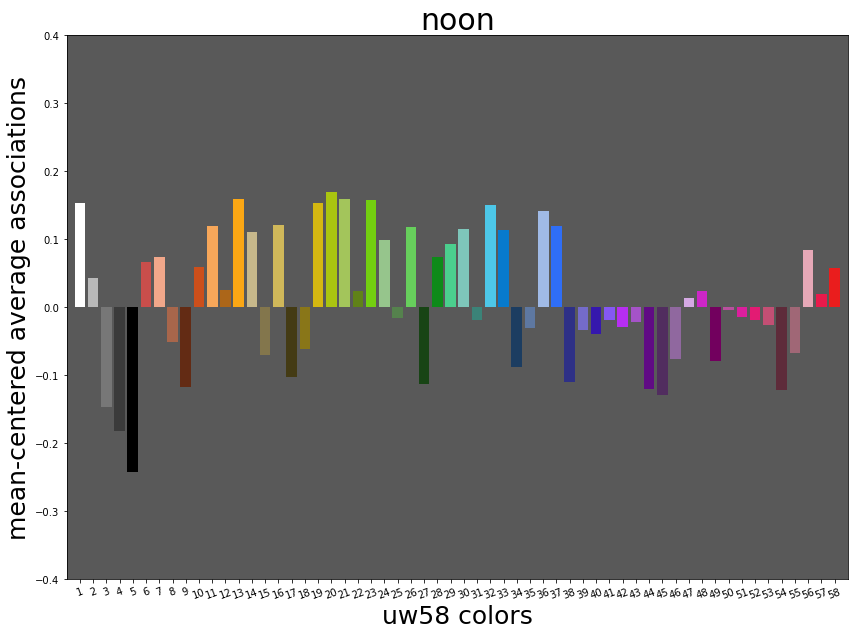

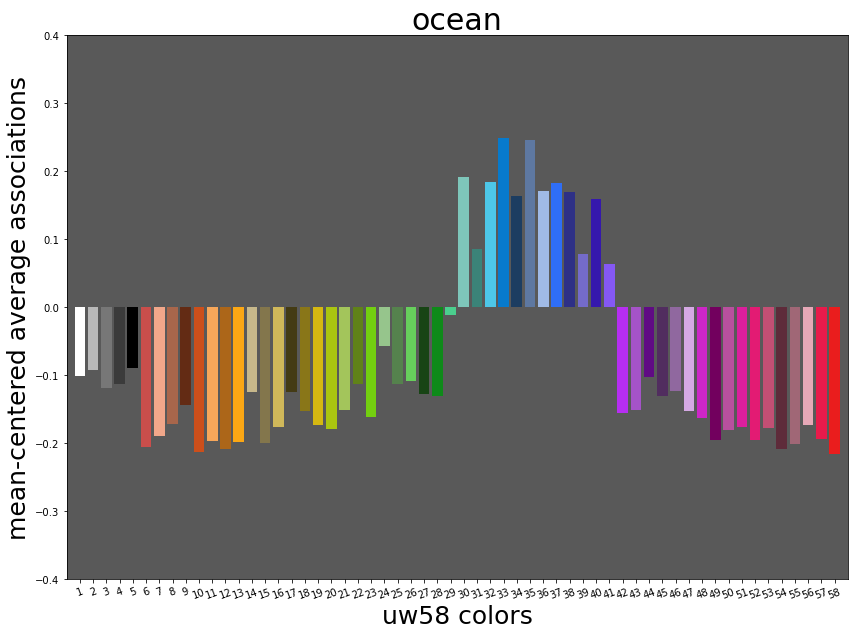

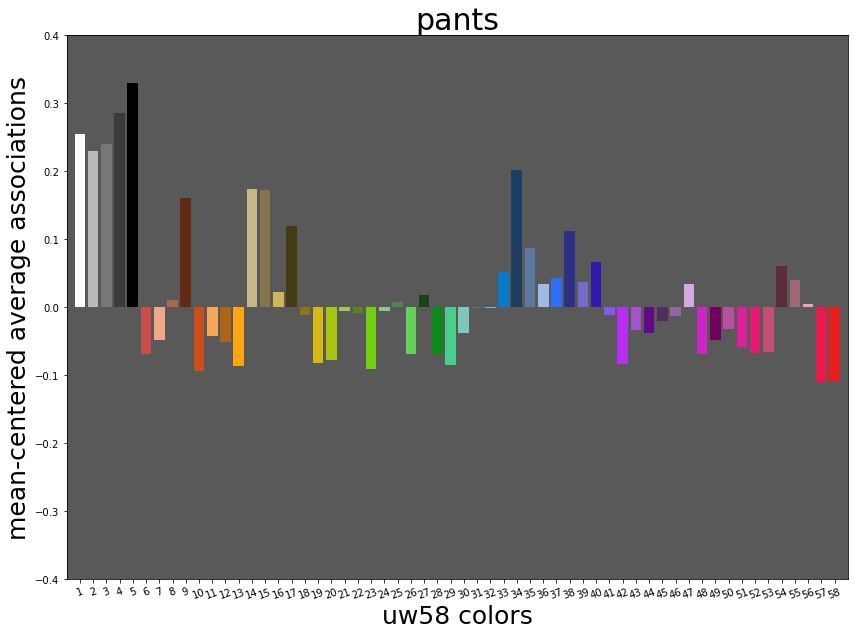

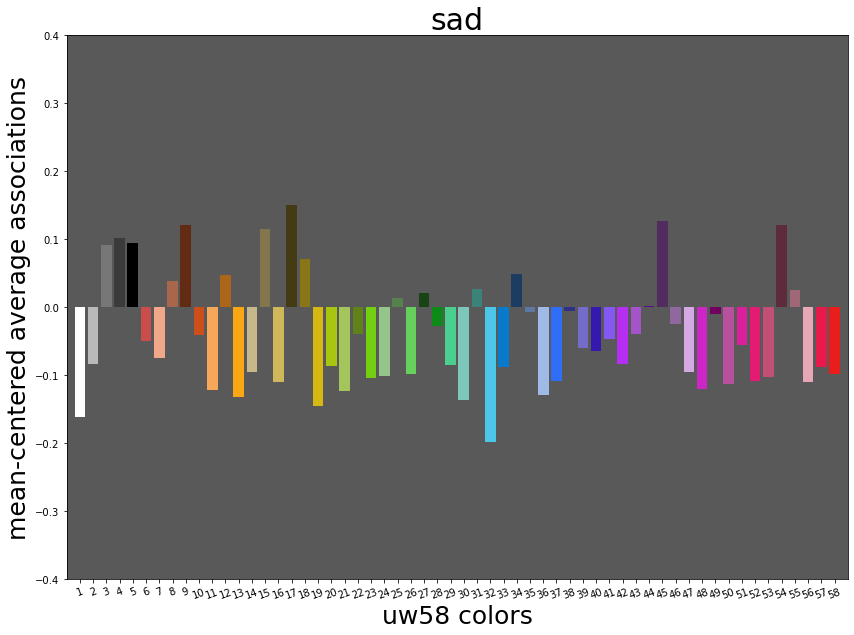

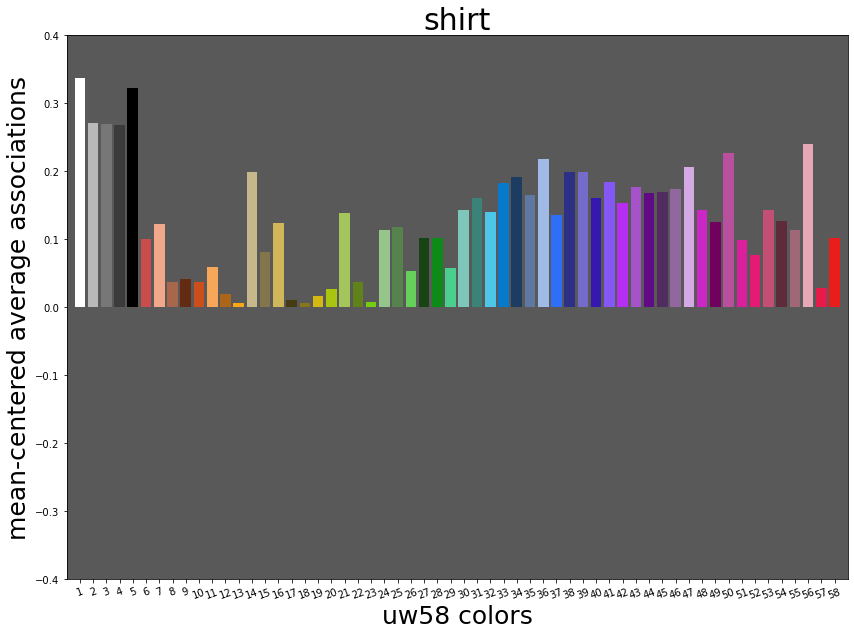

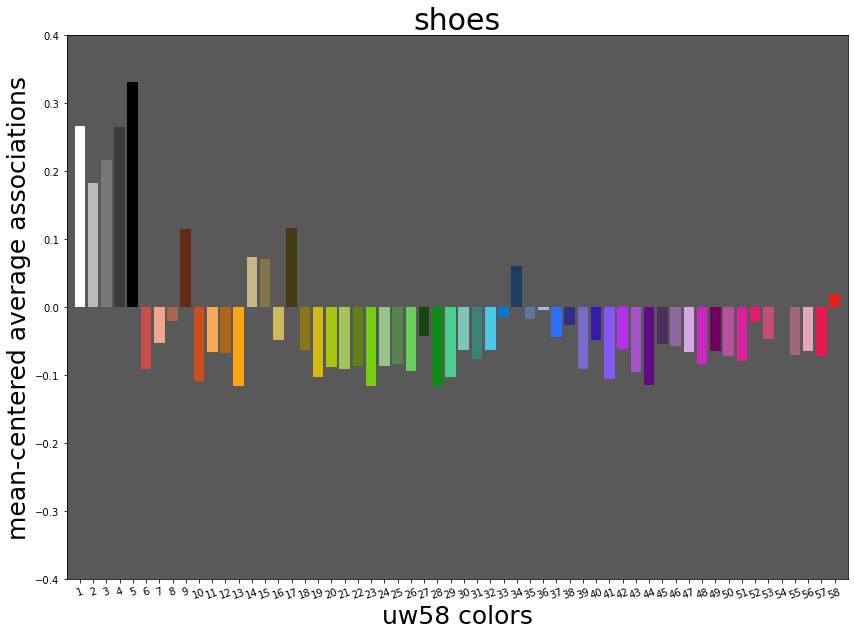

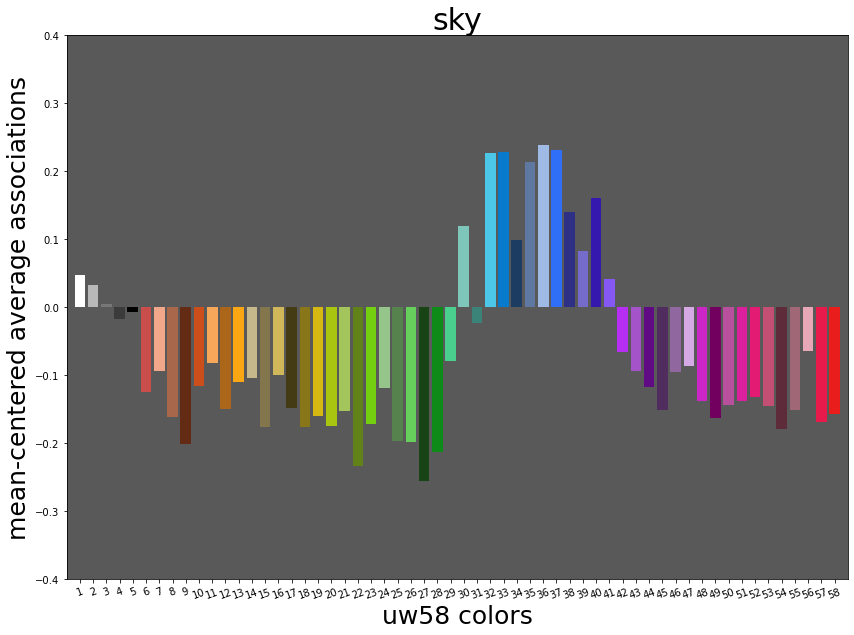

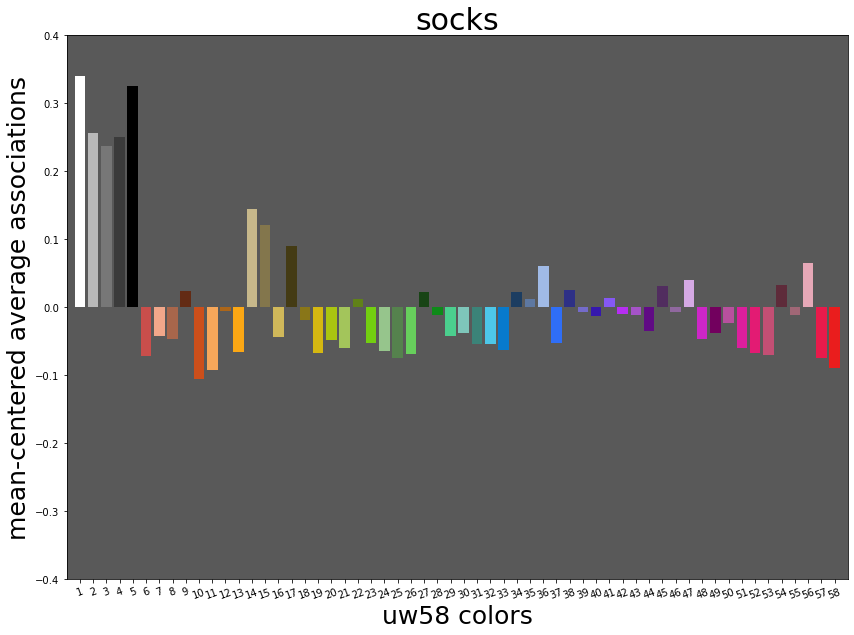

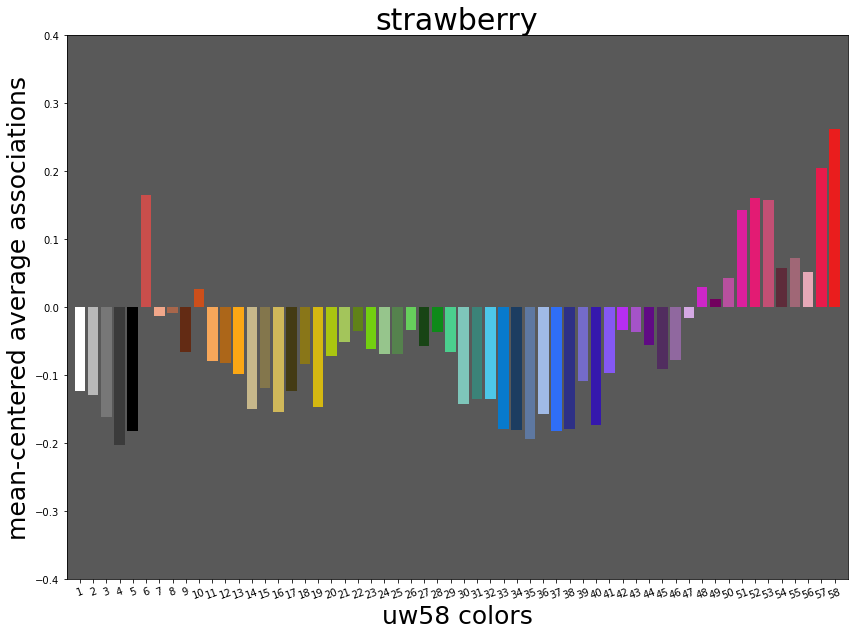

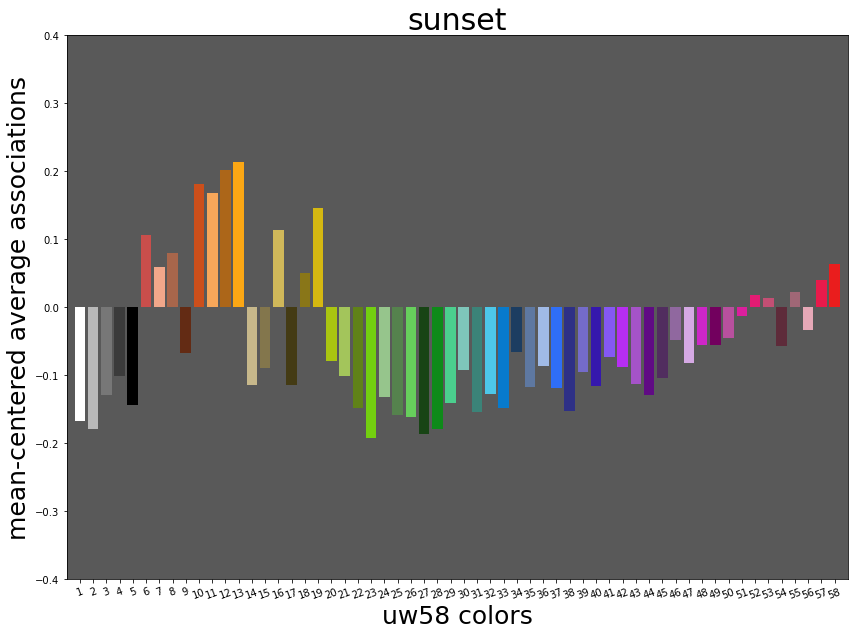

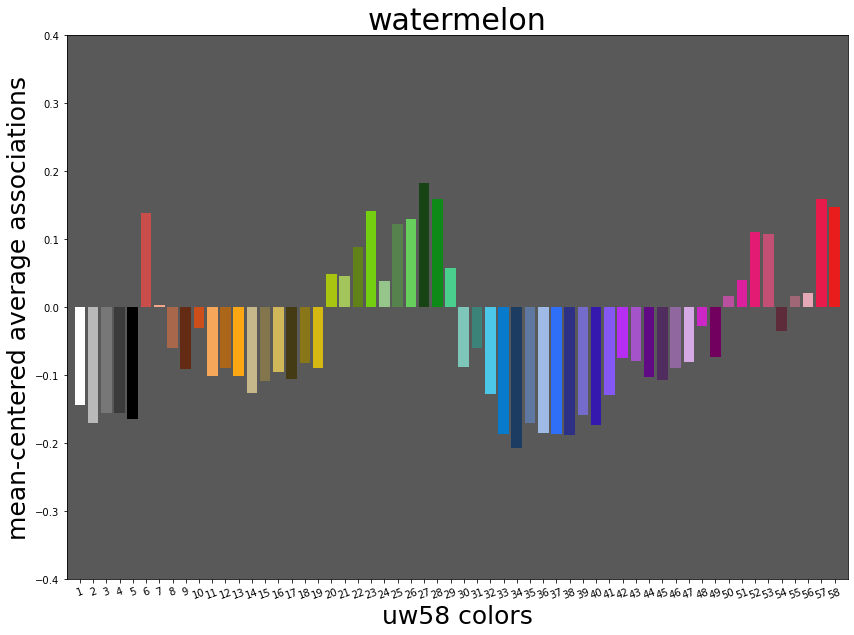

In [145]:
for con in np.unique(cca_df.concepts):
  ds = cca_df[cca_df.concepts==con]

  # sorted_values = ds.iloc[0,4:].sort_values(ascending=False).index.values
  # c=[]
  # for ind in sorted_values:
  #     c.append(int(ind.split('V')[1]))
  # d=[]
  # for num in c:
  #   d.append(uw_58_cdict[uw_58_cdict['index']==num]['hex'].values[0])
  plt.figure(figsize=(14,10))
  ds_cols = ds.iloc[0,4:]
  
  plt.bar(np.arange(58),ds_cols.iloc[sorted_col_order-1].values,color=np.array(uw_58_cdict.iloc[sorted_col_order-1,:]['hex'].values))

  # plt.bar(np.arange(58),ds.iloc[0,4:].sort_values(ascending=False).values,color=np.array(d))
  plt.title(con,fontsize=30) 
  plt.ylim(-.4,.4)
  plt.xlim(-1,58)

  plt.xticks(ticks=range(58),labels=range(1,59),rotation=20,fontsize=10)
  # plt.savefig(f"{con}_dist.pdf", format='pdf')
  # files.download(f"{con}_dist.pdf") 

  ax = plt.gca()
  ax.set_facecolor((89.05/255,89.05/255,89.05/255))
  plt.xlabel('uw58 colors',fontsize=25)
  plt.ylabel('mean-centered average associations',fontsize=25)

 
  plt.savefig(f'../plots/{con}_dist_unsorted.pdf', format='pdf')
  plt.show()



V1     0.142068
V2    -0.017296
V3      0.08586
V4     0.088875
V5     0.022426
V6      0.04334
V7     0.070814
V8     0.024522
V9       0.1116
V10    0.098596
V11    0.110074
V12    0.082826
V13    0.090583
V14    0.012641
V15    0.108445
V16    0.149881
V17    0.158886
V18    0.083729
V19    0.098859
V20    0.117014
V21    0.026965
V22    0.159364
V23   -0.003243
V24    -0.13234
V25   -0.053143
V26    0.009578
V27    0.105304
V28    0.011093
V29    0.007177
V30    0.062779
V31    0.109833
V32     0.11834
V33    -0.07323
V34    0.006007
V35    0.077405
V36    0.110708
V37   -0.019359
V38   -0.044877
V39   -0.016465
V40   -0.032479
V41    0.040755
V42    0.079054
V43    0.042215
V44    0.145792
V45    0.003217
V46    0.051914
V47   -0.001883
V48    0.089546
V49    0.005729
V50    0.109472
V51    0.016642
V52    0.086448
V53    0.081872
V54    0.114226
V55     0.08842
V56    0.094356
V57    0.105951
V58    0.099664
Name: 5, dtype: object

In [91]:
uw_58_cdict

,hex,index,hue_angle,saturation,lightness
0,#0e8a19,47,0.348118,76.0,-0.826667
1,#ac6619,51,0.087302,98.5,-0.753846
2,#608218,45,0.220126,77.0,-0.697368
3,#96c58c,35,0.304094,168.5,-0.170149
4,#443b14,37,0.135417,44.0,-0.558140
5,#a0bae6,4,0.604762,195.0,-0.180412
6,#cc4f1b,53,0.048964,115.5,-0.772926
7,#b9b9b9,26,0.000000,185.0,0.000000
8,#7ec6ba,22,0.472222,162.0,-0.223602
9,#3518ad,18,0.699105,98.5,-0.764103


Text(0.5, 1.0, 'symb cor matrix')

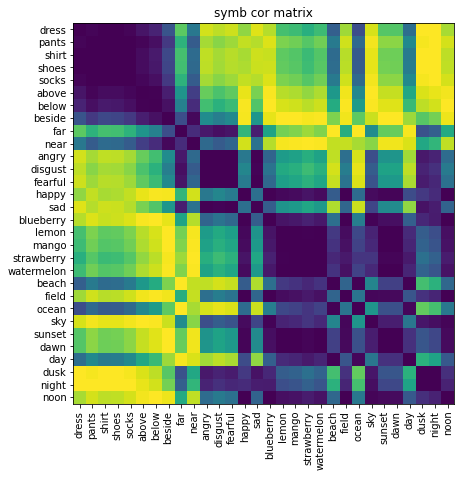

In [462]:
plt.figure(figsize=(10,7))
plt.imshow(np.corrcoef(sym3d_df.iloc[:,1:]), cmap='viridis_r')
plt.yticks(ticks = range(30),labels = list(concept_list))
plt.xticks(ticks = range(30),labels = list(concept_list), rotation=90)
plt.title('symb cor matrix')

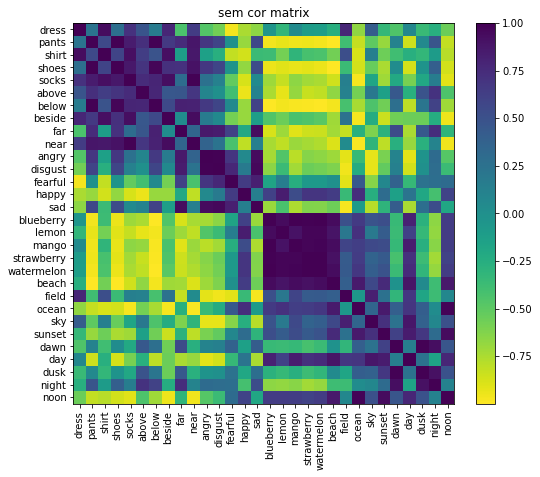

In [157]:
plt.figure(figsize=(10,7))
plt.imshow(cosine_similarity(kind3d_df.iloc[:,1:]), cmap='viridis_r')
plt.yticks(ticks = range(30),labels = list(concept_list))
plt.xticks(ticks = range(30),labels = list(concept_list), rotation=90)
plt.title('sem cor matrix')
cb = plt.colorbar(fraction=0.046, pad=0.04)
plt.savefig('../plots/kind_colorbar.pdf',format='pdf')

In [153]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity(kind3d_df.iloc[:,1:]).shape

(30, 30)

Text(0.5, 1.0, 'col cor matrix')

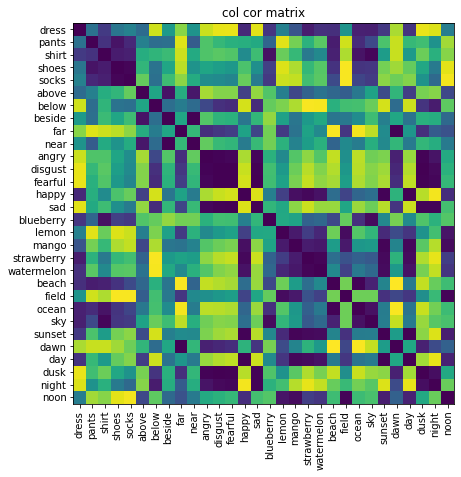

In [158]:
plt.figure(figsize=(10,7))
plt.imshow(cosine_similarity(col3d_df.iloc[:,1:]), cmap='viridis_r')
plt.yticks(ticks = range(30),labels = list(concept_list))
plt.xticks(ticks = range(30),labels = list(concept_list), rotation=90)
plt.title('col cor matrix')

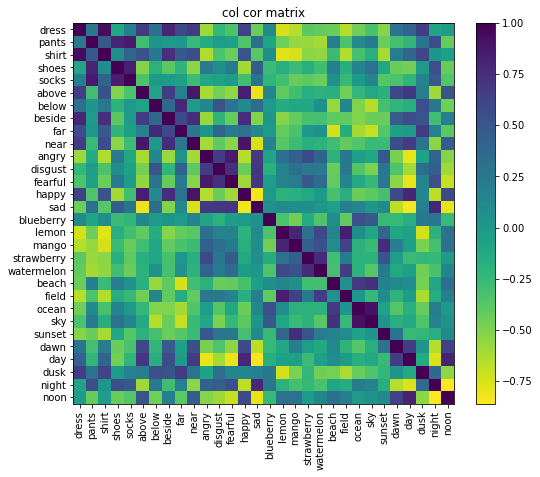

In [160]:
plt.figure(figsize=(10,7))
plt.imshow(cosine_similarity(cca_df.iloc[:,4:]), cmap='viridis_r')
plt.yticks(ticks = range(30),labels = list(concept_list))
plt.xticks(ticks = range(30),labels = list(concept_list), rotation=90)
plt.title('col cor matrix')
cb = plt.colorbar(fraction=0.046, pad=0.04)